# A 3T gain-cell (GC-eDRAM) memory compiler, from bitcell to signed-off hard block

**IEEE SSCS Code-a-Chip, ISSCC 2027** &nbsp;·&nbsp; licensed under the [Apache License 2.0](https://github.com/barakhoffer/gc_compiler/blob/v1.0/LICENSE)
&nbsp;·&nbsp; code: [github.com/barakhoffer/gc_compiler](https://github.com/barakhoffer/gc_compiler/tree/v1.0) (release `v1.0`) &nbsp;·&nbsp;
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/barakhoffer/gc_compiler/blob/v1.0/notebooks/gain_cell_compiler.ipynb)

**Author**
| Name | Email | IEEE / SSCS member |
|---|---|---|
| *Barak Hoffer* | *barak.hoffer@gmail.com* | *no* |

**Abstract.** Gain-cell eDRAM stores a bit on a transistor's gate in an ordinary logic process: no
capacitor module, two ports, roughly half an SRAM cell's area -- but the charge leaks, so every row
needs refreshing, and a usable memory needs a cell, an array, its periphery, timing that holds at
every corner and a refresh controller. `gc_compiler` generates all of it from a few parameters, in
Python on gdsfactory, entirely with open-source tools: a 3T gain-cell bitcell, mirrored and tapped
arrays, word-line drivers, column circuits, a pitch-matched decoder and a replica column into a
DRC-clean, LVS-matched macro; post-layout timing at five corners with local-mismatch Monte Carlo;
retention measured on the extracted macro; a synthesizable refresh controller; and, with
LibreLane, the macro and its controller as one signed-off hard block. Everything process-specific is
in one technology adapter: the same compiler builds for SkyWater **sky130** and IHP **SG13G2**, each
checked against its own foundry decks.

**Results at a glance** (this notebook's own runs, sky130, unless noted):

| | |
|---|---|
| Bitcell (default: LVT write, 0.5 um `mr`) | 1.270 x 2.630 um = 3.34 um2 (plain 3T: 3.00 um2) |
| Macro, 2 x 16x20 / 2 x 128x128 | 18.3 / 6.48 um2 per bit, DRC clean, LVS matched |
| Read access at tt | 1.14 ns (2 x 16x20); 3.7-4.1 ns (2 x 128x128) |
| Retention (refresh interval, ss, 125 C) | 703 us; 614 us for the worst of 20 mismatch dies (12x the plain cell) |
| In-macro refresh (the column writes the row back itself) | restores at every corner; 0 of 20 mismatch dies fail at ss |
| Hard block, 2 x 128x128 (macro + controller, LibreLane) | 290,975 um2, DRC/LVS/antenna clean, timing met at tt/ss/ff, gate-level testbench passing |
| Refresh controller | 2,095 um2 at 16x20 (49 flops and latches), 9,066 um2 at 2 x 128x128 (4.3% of the macro) |
| IHP SG13G2 port | the same macro clean under IHP's KLayout decks, LVS matched; 100 us refresh interval (worst die, ss) |

**What is new here** (each worked out in the section named):

* **A memory compiler written against a technology abstraction**, checked on a second, quite
  different real process (section 24).
* **Self-timed reads**: a replica column's `rdy` ends every read in the decoder, so no fixed read time
  has to be right at every corner (sections 14, 20).
* **Refresh written back inside the macro**: each column's write driver is `NAND(din, rbl)`, so a
  refresh never moves data through the controller (section 21).
* **A small refresh controller and a signed-off hard block** from one call: latched `dout`, no copy of
  the user's request, a band sized for the wires that cross the banks (sections 21, 23).
* **Two answers to the gain cell's weak write '0'** -- a negative write rail and a supply-free
  LVT write with a longer read gate -- measured against each other (sections 15-17).

**How it is told.** Sections 5-16 build the compiler up from the plain 3T cell, one problem at a
time, so their code asks for it explicitly: `BitcellConfig.plain()` and `ArrayConfig.basic()` (no
replica column, no self-timing, no straps, minimum drivers). Each later section adds what the
earlier ones found missing, and the compiler's defaults are where the story ends (section 22): the
LVT-write cell, a replica column with self-timed reads, in-macro refresh, two banks around
one decoder, and strapped, stronger word lines on wide arrays.

**Running it.** Locally, from the project's nix shell with
KLayout, magic, netgen, ngspice, iverilog, LibreLane and the PDKs on the path; or on Google Colab, where the setup cells of section 0 install the same tools, both PDKs and the compiler at the
release `v1.0`. A full local run takes about 80 minutes, about 55 of them the 2 x 128x128 hard block
(section 23); everything else takes about 15 minutes, and Colab's two cores run slower. On Colab
`FULL` is off by default: the 2 x 128x128 DRC/LVS is skipped, and the hard blocks need
`INSTALL_LIBRELANE = True` (untested there) -- their stored outputs are from a full local run.

**Contents**:

0. Setup
1. Why gain cells?
2. The 3T gain cell
3. Compiler architecture
4. The primitive: a diffusion strip with a series device stack
5. The bitcell
6. Tiling: mirrored row pairs and tap rows
7. The netlist
8. Sign-off DRC
9. Retention and read, in ngspice
10. Design-space exploration
11. Periphery
12. LVS: does the layout actually match the netlist?
13. Address decoding
14. A replica bit line, and timing
15. A negative write word line
16. A supply-free alternative: LVT write + a longer read gate
17. The default cell: an LVT write and a longer `mr` only
18. Two banks around one decoder
19. Wide arrays: word-line straps and stronger drivers
20. Self-timed reads
21. Refresh
22. The defaults
23. A larger macro: 2 x 128x128
24. Porting to another process


## 0. Setup

**Locally** these cells only check that the tools are
there. **On Google Colab** they install them: step 1 Nix, the package manager the project's tools
come from (the same install LibreLane's own Colab notebook uses, with the FOSSi Foundation's binary
cache); step 2 (a few minutes) KLayout and magic (DRC), magic and netgen (LVS), ngspice (SPICE) and
iverilog (Verilog) from nixpkgs, as in `shell.nix`, the sky130 and IHP SG13G2 PDKs at the versions
the compiler is verified with, and the compiler itself, at the release `TAG`. `FULL` (default: on
locally, off on Colab) runs everything; off, the slowest cells are skipped and keep their stored
outputs.

In [ ]:
import os
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
#: the compiler release this notebook goes with (on Colab it is cloned at this tag)
TAG = "v1.0"
#: run everything, or skip the slowest cells (their stored outputs, from a full run, stay): by
#: default run everything
FULL = True
if IN_COLAB:
    os.environ["LOCALE_ARCHIVE"] = "/usr/lib/locale/locale-archive"
    if shutil.which("nix-env") is None:
        with tempfile.TemporaryDirectory() as d:
            installer = Path(d) / "nix"
            !curl -fsSL https://install.determinate.systems/nix > {installer}
            # without systemd (a container), Nix runs single-user, as root, with no daemon
            init = [] if Path("/run/systemd/system").exists() else ["linux", "--init", "none"]
            subprocess.run(
                [
                    "sh", str(installer), "install", *init, "--prefer-upstream-nix", "--no-confirm", "--extra-conf",
                    "extra-substituters = https://nix-cache.fossi-foundation.org\n"
                    "extra-trusted-public-keys = nix-cache.fossi-foundation.org:3+K59iFwXqKsL7BNu6Guy0v+uTlwsxYQxjspXzqLYQs=\n",
                ],
                check=True,
            )
    os.environ["PATH"] = f"/nix/var/nix/profiles/default/bin:{os.environ['PATH']}"
    print("nix:", shutil.which("nix"))
else:
    print("running locally: the tools come from the project's nix shell")

running locally: the tools come from the project's nix shell


In [ ]:
if IN_COLAB:
    # the tools at the nixpkgs revision they are verified with
    !nix profile install github:NixOS/nixpkgs/4c7870105e7f1fdf9c48688c8d7efc21abf0688a#klayout github:NixOS/nixpkgs/4c7870105e7f1fdf9c48688c8d7efc21abf0688a#magic-vlsi github:NixOS/nixpkgs/4c7870105e7f1fdf9c48688c8d7efc21abf0688a#netgen-vlsi github:NixOS/nixpkgs/4c7870105e7f1fdf9c48688c8d7efc21abf0688a#ngspice github:NixOS/nixpkgs/4c7870105e7f1fdf9c48688c8d7efc21abf0688a#iverilog

    # the sky130 and IHP SG13G2 PDKs, the versions this repository is verified with
    PDK_ROOT = "/content/pdk"
    %pip install -q ciel
    import ciel
    from ciel.source import StaticWebDataSource

    for family, version in (("sky130", "a492ff787163f93ce9ebc382b23c58c0de33afa3"), ("ihp-sg13g2", "5e6d592e4002946a4616f798c357f0f3c06cf3b6")):
        ciel.enable(
            ciel.get_ciel_home(PDK_ROOT), family, version,
            data_source=StaticWebDataSource("https://fossi-foundation.github.io/ciel-releases"),
        )
    os.environ["PDK_ROOT"] = PDK_ROOT

    # the compiler, at the release this notebook goes with
    if not Path("/content/gc_compiler").exists():
        !git clone -q --depth 1 --branch {TAG} https://github.com/barakhoffer/gc_compiler.git /content/gc_compiler
    # gdsfactory's dependencies first, pinned to what Colab's own packages accept, and gdsfactory itself
    # without its dependencies: installed the default way, it breaks the Colab environment
    %pip install \
      "jinja2<4" \
      "loguru<1" \
      "matplotlib<4" \
      numpy \
      "orjson<4" \
      pandas \
      "pydantic>=2" \
      "pydantic-settings<3" \
      "pydantic-extra-types<3" \
      pyyaml \
      qrcode \
      "rectpack<1" \
      "rich<16" \
      "scipy<2" \
      "shapely<3" \
      "toolz<2" \
      types-PyYAML \
      "typer<1" \
      "kfactory~=3.0.4" \
      "watchdog<7" \
      freetype-py \
      mapbox_earcut \
      networkx \
      scikit-image \
      "trimesh>=4.4.1" \
      attrs \
      graphviz \
      "pyglet<3" \
      typing-extensions \
      pygit2 \
      natsort
    %pip install gdsfactory --no-deps
    # the compiler without its dependencies too (gdsfactory, numpy and matplotlib are in by now): left to
    # resolve them, pip could pull gdsfactory's own list back in
    %pip install -q --no-deps -e /content/gc_compiler
    # a running kernel only reads an editable install's path hook at startup: add the sources directly
    if "/content/gc_compiler/src" not in sys.path:
        sys.path.insert(0, "/content/gc_compiler/src")
    %cd /content/gc_compiler/notebooks

missing = [tool for tool in ("klayout", "magic", "netgen", "ngspice", "iverilog") if shutil.which(tool) is None]
if missing:
    hint = "see the nix output above" if IN_COLAB else "start Jupyter from the nix shell: nix-shell --run 'uv run jupyter lab'"
    raise RuntimeError(f"not installed: {', '.join(missing)} -- {hint}")
import gc_compiler

print("tools, PDKs and gc_compiler ready")

tools, PDKs and gc_compiler ready


In [ ]:
# optional on Colab: LibreLane, for the hard-block builds of sections 21 and 23 (untested there;
# the 128x128 block takes much longer than on a workstation). Locally the nix shell provides it.
INSTALL_LIBRELANE = False
if IN_COLAB and INSTALL_LIBRELANE:
    !nix profile install github:NixOS/nixpkgs/4c7870105e7f1fdf9c48688c8d7efc21abf0688a#librelane github:NixOS/nixpkgs/4c7870105e7f1fdf9c48688c8d7efc21abf0688a#yosys github:NixOS/nixpkgs/4c7870105e7f1fdf9c48688c8d7efc21abf0688a#openroad github:NixOS/nixpkgs/4c7870105e7f1fdf9c48688c8d7efc21abf0688a#verilator
    !apt-get install -y -q python3-tk  # LibreLane reads the PDK's configuration with Tk
print("librelane:", shutil.which("librelane"))

librelane: /nix/store/h9ip44kirnzal00npba5yljbzvsqqf17-librelane/bin/librelane


## 1. Why gain cells?

A 6T SRAM cell stores a bit in a cross-coupled latch: it is fast and static, but it burns
leakage in six transistors, needs a careful read/write stability trade-off, and is
single-ported unless you add more devices.

A **gain cell** stores the bit as charge on the gate of a read transistor. That gate is a
pure capacitor, so:

* fewer devices, smaller cell, lower leakage (Harel *et al.*, 2022 report a **40 % area
  reduction** versus a 6T SRAM cell for a 64-kB 65-nm macro);
* the read port never disturbs the storage node, so reads are **non-destructive** and the
  cell is naturally **two-ported** (separate write and read bit lines);
* it is built from ordinary logic devices - no DRAM capacitor module, unlike 1T1C eDRAM;
* but the charge leaks away, so the cell needs **periodic refresh** (16 µs retention in
  that same 65-nm macro).


| Paper | Takeaway used here |
|---|---|
| Shalom, Giterman & Teman, *High Density GC-eDRAM Design in 16nm FinFET* (2018) | Topology and layout guidance: share polygons across cell boundaries and mirror aggressively; a 3T cell costs one extra poly pitch over a 2T cell but gives a far more robust read; use an HVT write device, paying for it with a word-line boost or a diminished data level. |
| Harel *et al.*, *64-kB 65-nm GC-eDRAM with Half-Select Support and Parallel Refresh* (2022) | Architecture: refresh is the real cost of GC-eDRAM; half-select support and replica bit lines belong in the periphery, not the bitcell. |
| He *et al.*, ISSCC 2024, *28nm 2.4 Mb/mm² eDRAM-LUT-based digital compute-in-memory macro* | Gain cells are still the density lever in modern compute-in-memory macros. |


## 2. The 3T gain cell




* **Write**: assert `wwl` low, `mw` passes the `wbl` level onto `sn`.
* **Hold**: `sn` floats on its own parasitic capacitance (gate of `ms` plus junctions).
* **Read**: precharge `rbl` high and assert `rwl`. If `sn` is high, `mr` and `ms` discharge
  `rbl`; if `sn` is low, `rbl` stays high. The storage node is never touched.

A PMOS write device passes a strong '1' and leaks less than an NMOS one, which is why it is
the write port here; the price is that a '0' is only written down to |Vtp| unless `wwl` is
driven below ground. We measure exactly that later in this notebook.

## 3. Compiler architecture

```
   config.py          BitcellConfig / ArrayConfig  - the knobs
        |
   tech/rules.py      LayerRole, DesignRules, Technology   <- process-independent
   tech/sky130.py     Sky130 adapter                       <- every sky130 value (checked: README, Porting)
        |
   primitives/        geometry, contacts, device stacks    <- generic builders
        |
   cells/             3T bitcell, tap row
        |
   array/             mirrored tiling, tap insertion
        |
   compiler.py        GDS + SPICE + metrics      verify/   DRC, ngspice
```

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from gc_compiler.array import array_geometry, gc_array
from gc_compiler.cells import bitcell_geometry, gain_cell_3t
from gc_compiler.compiler import GainCellCompiler
from gc_compiler.config import ArrayConfig, BitcellConfig
from gc_compiler.netlist import array_netlist, bitcell_subckt
from gc_compiler.tech import DeviceKind, LayerRole, Sky130, activate

tech = Sky130()
activate(tech)
rules = tech.rules

print(f"technology: {tech.name}")
for role in (LayerRole.DIFF, LayerRole.POLY, LayerRole.LI, LayerRole.M1, LayerRole.M2):
    print(
        f"  {role.value:5s} gds={tech.layer(role)}  "
        f"min width={rules.w(role):.2f} um  min space={rules.s(role):.2f} um"
    )
print(f"  minimum device W/L: {rules.device_min_width}/{rules.device_min_length} um")
print(f"  n-well encloses p+ diffusion by {rules.enc(LayerRole.NWELL, LayerRole.DIFF)} um")
print(f"  n-well keeps {rules.nwell_to_ndiff_space} um from n+ diffusion outside it")

technology: sky130A
  diff  gds=(65, 20)  min width=0.15 um  min space=0.27 um
  poly  gds=(66, 20)  min width=0.15 um  min space=0.21 um
  li    gds=(67, 20)  min width=0.17 um  min space=0.17 um
  m1    gds=(68, 20)  min width=0.14 um  min space=0.14 um
  m2    gds=(69, 20)  min width=0.14 um  min space=0.14 um
  minimum device W/L: 0.42/0.15 um
  n-well encloses p+ diffusion by 0.18 um
  n-well keeps 0.34 um from n+ diffusion outside it


## 4. The primitive: a diffusion strip with a series device stack

Both halves of the bitcell are built from one generic primitive: a vertical diffusion
strip crossed by horizontal poly gates. Current flows along *y*, so the transistor width
is the *x* extent of the strip and the gates are naturally shared by a whole row - exactly
what a word line needs.

The builder resolves the vertical budget from the design rules: contacted nodes cost a
contact plus its enclosure, uncontacted nodes (series devices sharing a diffusion node)
cost only the poly-to-poly spacing. The read stack below has an uncontacted node between
`ms` and `mr`, which is where a large part of the cell's density comes from.

read stack is 1.470 um tall
  gate centres at y = [0.22, 0.77]
  node contacts at y = [0.0, None, 1.18]


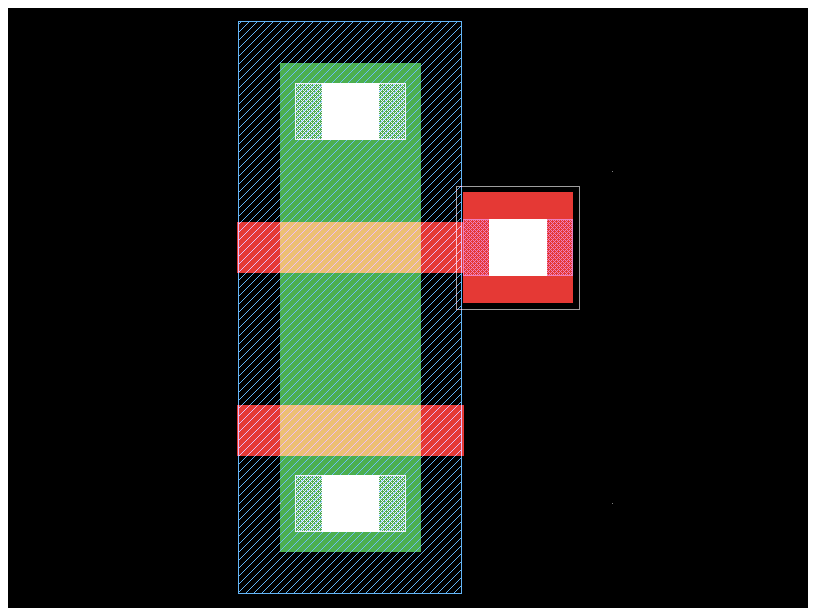

In [ ]:
import gdsfactory as gf

from gc_compiler.primitives import DeviceStack, Gate, Node, build_device_stack, plan_stack

read_stack = DeviceStack(
    kind=DeviceKind.NMOS,
    width=0.42,
    gates=(Gate("rwl", 0.15), Gate("sn", 0.15, pad="right")),
    nodes=(Node("rbl", boundary=True), Node("n_int", contact=False), Node("vss")),
)
plan = plan_stack(tech, read_stack)
print(f"read stack is {plan.height:.3f} um tall")
print(f"  gate centres at y = {[round(y, 3) for y in plan.gate_y]}")
print(f"  node contacts at y = {[None if y is None else round(y, 3) for y in plan.node_y]}")

demo = gf.Component("nb_read_stack")
build_device_stack(demo, tech, read_stack)
demo.plot(show_labels=False)

## 5. The bitcell

The write device sits directly **above** the read stack in the same column of the cell, in
an n-well band that spans the full cell width. That stacking is what lets both word lines
stay in poly and both bit lines stay in a single metal-2 track per column.

Three sharing tricks, straight out of the FinFET density paper, set the pitch:

1. **`rbl` and `wbl` contacts sit exactly on the cell boundary.** Rows are mirrored in
   pairs, so two vertically adjacent cells share one diffusion contact - halving the
   junction capacitance a read sees on `rbl`, which is the dominant read-path load.
2. **The n-well band merges** across the shared `wbl` boundary, so a mirrored row pair pays
   for one well-to-n+ spacing instead of two.
3. **Word lines are poly stripes drawn across the full pitch**, so they connect by
   abutment; only the `sn` gate is a local island with a contact pad.

bitcell: 1.220 x 2.460 um = 3.001 um2
  rbl track x=0.340   wbl track x=0.715
  rwl y=0.220   wwl y=2.225   vss rail y=1.180
  n-well band y=[1.665, 2.785]
  ports: ['rbl', 'rwl', 'vss', 'wbl', 'wwl']


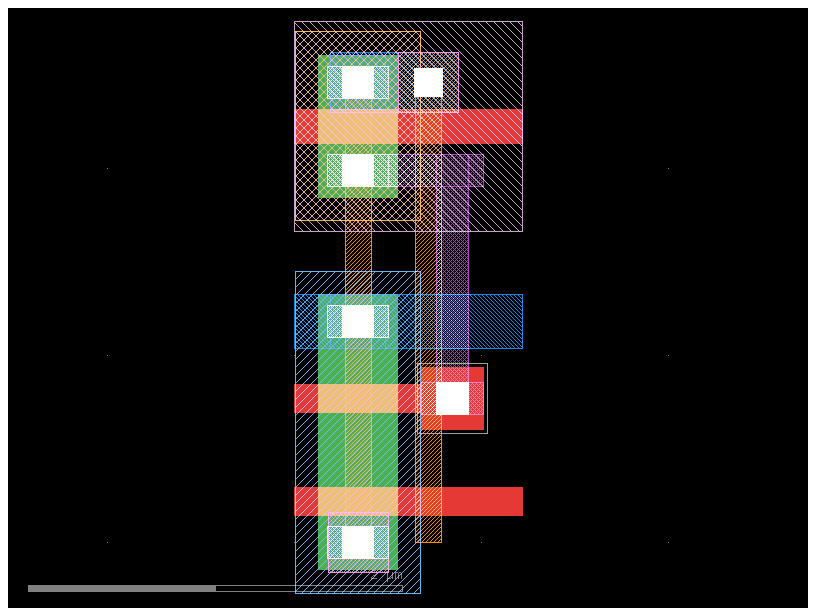

In [ ]:
cell_cfg = BitcellConfig.plain()
geo = bitcell_geometry(tech, cell_cfg)
cell = gain_cell_3t(tech, cell_cfg)

print(f"bitcell: {geo.pitch_x:.3f} x {geo.pitch_y:.3f} um = {geo.area:.3f} um2")
print(f"  rbl track x={geo.rbl_x:.3f}   wbl track x={geo.wbl_x:.3f}")
print(f"  rwl y={geo.rwl_y:.3f}   wwl y={geo.wwl_y:.3f}   vss rail y={geo.vss_y:.3f}")
print(f"  n-well band y=[{geo.nwell_y0:.3f}, {geo.nwell_y1:.3f}]")
print(f"  ports: {sorted(p.name for p in cell.ports)}")
cell.plot(show_labels=False)

For scale: a 6T SRAM cell in sky130's high-density library is about 1 µm². A 3T gain cell
drawn to the same *logic* design rules cannot beat that - published gain cells rely on
pushed, memory-specific rules that an open PDK does not expose. What the gain cell buys
here is the two-ported, low-leakage behaviour, and a cell that scales with whatever rules
the adapter is given.

## 6. Tiling: mirrored row pairs and tap rows

Rows alternate orientation. Row 0 is drawn as-is, row 1 is mirrored about their shared
`wbl` boundary, so the pattern of boundaries up a column is
`rbl | wbl | rbl | wbl | ...`, and every boundary is a shared contact.

Well and substrate taps go into dedicated **tap rows** inserted at `rbl` boundaries, where
the neighbouring rows present only n+ diffusion. Each tap row carries a p+ strip tied to
`vss` and an n+ strip in its own n-well tied to `vnw`, with the bit lines running straight
through on metal 2.

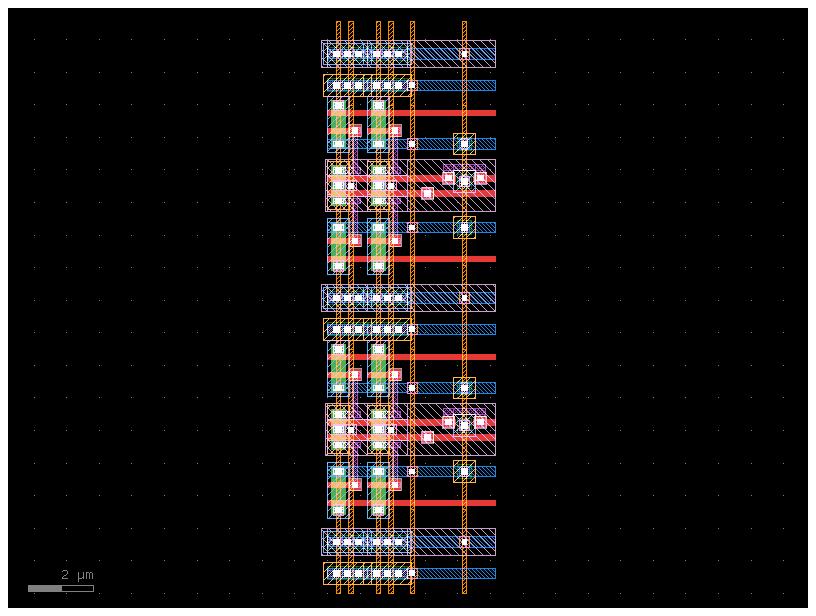

In [ ]:
small = gc_array(tech, ArrayConfig.basic(rows=4, cols=2, tap_row_interval=1), name="nb_array_4x2")
small.plot(show_labels=False)

Look at the column boundaries in the plot above: the green diffusion contacts on the row
boundaries belong to two cells at once, and the pink n-well bands of the mirrored pairs
have merged into single stripes. The wide horizontal bands are the tap rows.

In [ ]:
cfg = ArrayConfig.basic(rows=32, cols=32, tap_row_interval=4)
compiler = GainCellCompiler(cfg, tech)
metrics = compiler.metrics()
for key, value in metrics.items():
    print(f"{key:>22}: {value}")

                  name: gc_array_32x32_plain
            technology: sky130A
                  rows: 32
                  cols: 32
                  bits: 1024
           transistors: 3072
        replica_column: False
     negative_write_wl: False
       wordline_straps: False
       cell_pitch_x_um: 1.22
       cell_pitch_y_um: 2.46
         cell_area_um2: 3.0012
              tap_rows: 5
     tap_row_height_um: 2.565
              width_um: 47.16999999999997
             height_um: 91.545
              area_um2: 4318.177649999998
      area_per_bit_um2: 4.216970361328123
      array_efficiency: 0.7116957775000298


nb_array_8x8: 8x8 = 64 bits, 12.47 x 24.81 um, 4.834 um2/bit
  build/nb_array_8x8.gds
  build/nb_array_8x8.spice
  build/nb_array_8x8.json


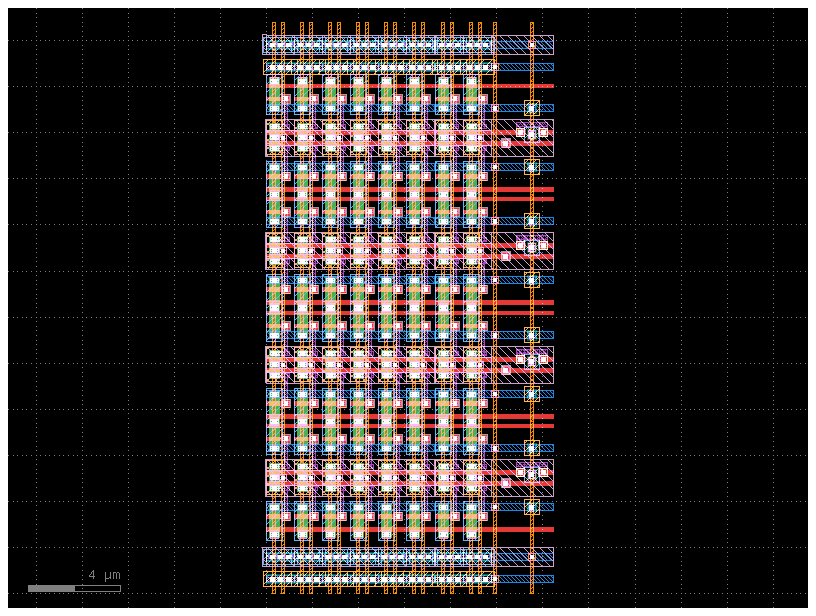

In [ ]:
result = GainCellCompiler(ArrayConfig.basic(rows=8, cols=8), tech).build("build", name="nb_array_8x8", macro=False)
print(result)
print(f"  {result.gds}\n  {result.spice}\n  {result.metrics_file}")
result.component.plot(show_labels=False)

## 7. The netlist

The netlist is generated from the same configuration objects as the layout, so the two
cannot drift apart. Device model names and the pin order of a device come from the
technology adapter - the netlist writer itself is process-independent.

In [ ]:
print(bitcell_subckt(tech, cell_cfg))
print()
print("\n".join(array_netlist(tech, ArrayConfig.basic(rows=2, cols=2)).splitlines()[-6:]))

.subckt gc3t wwl wbl rwl rbl vss vnw
* mw: write transistor, wbl -> sn under wwl control
Xmw wbl wwl sn vnw sky130_fd_pr__pfet_01v8 w=0.42 l=0.18
* mr: read transistor, gated by the storage node
Xmr n_int sn vss vss sky130_fd_pr__nfet_01v8 w=0.42 l=0.15
* ms: read select
Xms rbl rwl n_int vss sky130_fd_pr__nfet_01v8 w=0.42 l=0.15
.ends

.subckt gc_array_2x2_plain wwl_0 wwl_1 rwl_0 rwl_1 wbl_0 wbl_1 rbl_0 rbl_1 vss vnw
Xbit_0_0 wwl_0 wbl_0 rwl_0 rbl_0 vss vnw gc3t
Xbit_0_1 wwl_0 wbl_1 rwl_0 rbl_1 vss vnw gc3t
Xbit_1_0 wwl_1 wbl_0 rwl_1 rbl_0 vss vnw gc3t
Xbit_1_1 wwl_1 wbl_1 rwl_1 rbl_1 vss vnw gc3t
.ends


## 8. Sign-off DRC

The generated GDS is checked with the PDK's own KLayout deck
(`sky130A_mr.drc`, front end + back end + off-grid checks). Nothing in the compiler knows
about that deck; it is a plain subprocess wrapper that parses the report.

In [ ]:
from gc_compiler.verify import run_drc

report = run_drc(result.gds)
print(report)

DRC clean: nb_array_8x8.gds


## 9. Retention and read, in ngspice

The testbench writes the cell once and then reads it periodically while the storage node
leaks. Because reads are non-destructive, a single transient shows the whole story: the
`sn` trace drifts, and the `rbl` level reached by each read tracks that drift until the
read fails. That failure point is the **data retention time**.

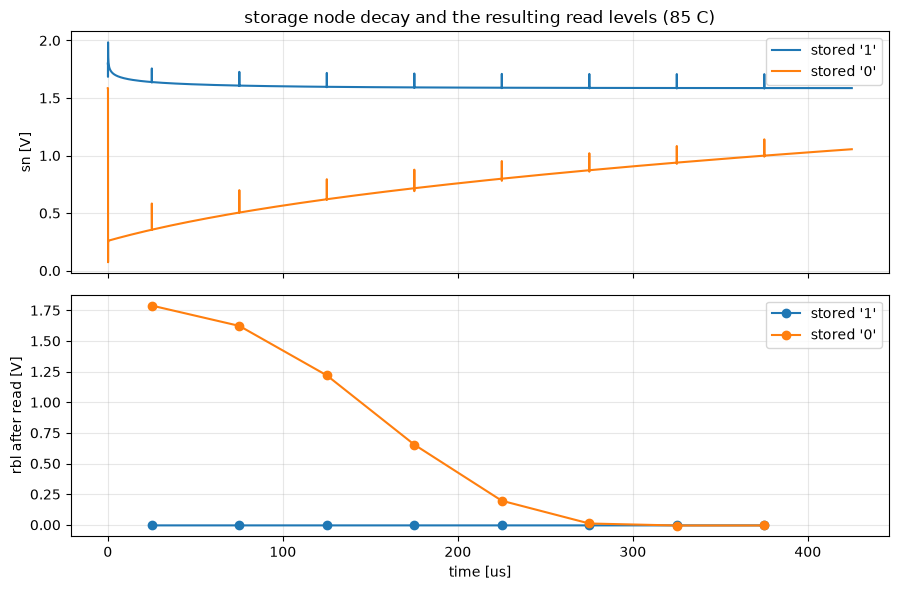

In [ ]:
from gc_compiler.verify import RetentionTestbench, run_retention

runs = {
    data: run_retention(
        tech,
        cell_cfg,
        RetentionTestbench(data=data, temperature=85.0, hold_time=400e-6, reads=8),
        workdir="build/sim/nb",
    )
    for data in (1, 0)
}

fig, (ax_sn, ax_bl) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for data, run in runs.items():
    ax_sn.plot(run.time * 1e6, run["sn"], label=f"stored '{data}'")
    times, levels = zip(*run.read_levels())
    ax_bl.plot(np.array(times) * 1e6, levels, "o-", label=f"stored '{data}'")
ax_sn.set_ylabel("sn [V]")
ax_sn.set_title("storage node decay and the resulting read levels (85 C)")
ax_bl.set_ylabel("rbl after read [V]")
ax_bl.set_xlabel("time [us]")
for ax in (ax_sn, ax_bl):
    ax.grid(alpha=0.3)
    ax.legend()
fig.tight_layout()

The '1' state barely moves: the storage node sits at VDD and the write PMOS is hard off.
The '0' state is the weak one - junction and GIDL leakage from the n-well into the p+ drain
of `mw` charges `sn` upwards until `mr` turns on and the read no longer distinguishes the
two states. With a PMOS write port the low state is always the retention-limiting one, and
it is the reason gain-cell macros refresh.

In [ ]:
def retention_time(run, vdd=1.8, margin=0.5):
    """First read at which a stored '0' fails to hold rbl above `margin` * vdd."""
    for t, level in run.read_levels():
        if level < margin * vdd:
            return t
    return None


for temperature in (27.0, 55.0, 85.0):
    run = run_retention(
        tech,
        cell_cfg,
        RetentionTestbench(data=0, temperature=temperature, hold_time=1e-3, reads=10),
        workdir=f"build/sim/temp{temperature:.0f}",
    )
    drt = retention_time(run)
    shown = f"{drt * 1e6:.0f} us" if drt else "> 1 ms"
    print(f"{temperature:5.0f} C -> data retention time {shown}")

   27 C -> data retention time 150 us


   55 C -> data retention time 150 us


   85 C -> data retention time 250 us


### The cost of a PMOS write port

A PMOS device cannot pull `sn` below |Vtp|, so a '0' written with `wwl` at ground starts
out degraded and the cell loses retention before it ever leaks. The standard fix - used in
every gain-cell paper - is to drive the write word line **below ground** (or to boost it
above VDD for an NMOS write port). Harel *et al.* avoid the boost altogether by adding an
explicit capacitor to the cell (a 3T-1C bitcell); here we simply expose the low level as a
knob and measure it.

In [ ]:
for wwl_low in (0.0, -0.2, -0.4):
    run = run_retention(
        tech,
        cell_cfg,
        RetentionTestbench(data=0, wwl_low=wwl_low, temperature=85.0, hold_time=200e-6, reads=4),
        workdir=f"build/sim/wwl{wwl_low}",
    )
    written = run["sn"][np.argmin(np.abs(run.time - 200e-9))]
    first_read = run.read_levels()[0][1]
    print(
        f"wwl low = {wwl_low:+.1f} V -> sn written to {written:.3f} V, "
        f"first read leaves rbl at {first_read:.3f} V"
    )

wwl low = +0.0 V -> sn written to 0.518 V, first read leaves rbl at 1.409 V


wwl low = -0.2 V -> sn written to 0.382 V, first read leaves rbl at 1.705 V


wwl low = -0.4 V -> sn written to 0.247 V, first read leaves rbl at 1.788 V


## 10. Design-space exploration

Because the cell is generated from rules rather than drawn, sweeping a device parameter is
a loop. A longer write device is the classic retention lever (less sub-threshold leakage
onto `sn`); here is what it costs in area.

In [ ]:
print(f"{'write L':>8} {'write W':>8} {'pitch x':>8} {'pitch y':>8} {'area':>8}")
for length in (0.15, 0.18, 0.25, 0.35):
    for width in (0.42, 0.65):
        g = bitcell_geometry(tech, BitcellConfig.plain(write_length=length, write_width=width))
        print(
            f"{length:8.2f} {width:8.2f} {g.pitch_x:8.3f} {g.pitch_y:8.3f} {g.area:8.3f}"
        )

 write L  write W  pitch x  pitch y     area
    0.15     0.42    1.220    2.430    2.965
    0.15     0.65    1.450    2.430    3.524
    0.18     0.42    1.220    2.460    3.001
    0.18     0.65    1.450    2.460    3.567
    0.25     0.42    1.220    2.530    3.087
    0.25     0.65    1.450    2.530    3.669
    0.35     0.42    1.220    2.630    3.209
    0.35     0.65    1.450    2.630    3.813


In [ ]:
print(f"{'array':>10} {'width':>9} {'height':>9} {'um2/bit':>9} {'efficiency':>11}")
for rows, cols in ((16, 16), (32, 32), (64, 64), (128, 128)):
    m = GainCellCompiler(ArrayConfig.basic(rows=rows, cols=cols), tech).metrics()
    print(
        f"{rows:>4}x{cols:<5} {m['width_um']:9.1f} {m['height_um']:9.1f} "
        f"{m['area_per_bit_um2']:9.3f} {m['array_efficiency']:10.1%}"
    )

     array     width    height   um2/bit  efficiency
  16x16         24.9      47.1     4.584      65.5%
  32x32         47.2      91.5     4.217      71.2%
  64x64         91.6     180.5     4.038      74.3%
 128x128       180.5     358.5     3.950      76.0%


## 11. Periphery

An array on its own is not a memory. The compiler adds three kinds of periphery, all built
from one **logic slice**: a CMOS pair drawn in the same orientation as the bitcell, with
the PMOS and NMOS columns side by side, a shared horizontal gate stripe and supply rails
running vertically over its own taps.

Drawing logic this way - a "rotated" standard cell - is what lets a driver hand its output
straight to a word-line poly stripe by abutment, and lets the same slice, rotated 90
degrees, pitch-match a bitcell column.


logic slice: 3.94 x 1.00 um
  pmos column x=[0.86, 1.50]
  nmos column x=[2.02, 2.44]
  gate row y=0.36, output row y=0.58


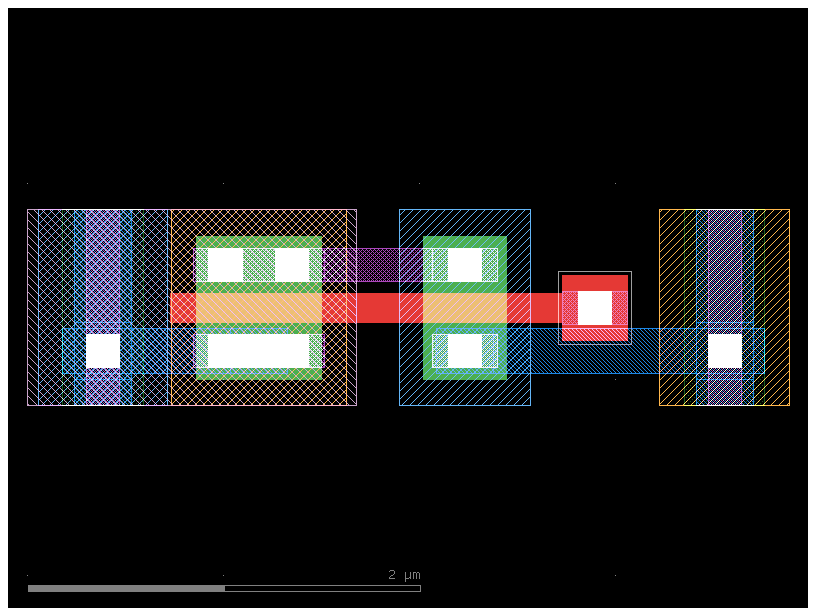

In [ ]:
from gc_compiler.periphery.logic import LogicConfig, inverter, logic_geometry

logic_cfg = LogicConfig()
slice_geo = logic_geometry(tech, logic_cfg)
print(f"logic slice: {slice_geo.width:.2f} x {slice_geo.pitch_y:.2f} um")
print(f"  pmos column x=[{slice_geo.pmos_x0:.2f}, {slice_geo.pmos_x1:.2f}]")
print(f"  nmos column x=[{slice_geo.nmos_x0:.2f}, {slice_geo.nmos_x1:.2f}]")
print(f"  gate row y={slice_geo.gate_y:.2f}, output row y={slice_geo.out_y:.2f}")
inverter(tech, logic_cfg, name="nb_inverter").plot(show_labels=False)


### Word-line drivers, and why they alternate sides

Mirroring the rows buys density, but it also pushes the two `wwl` stripes of a row pair to
within half a micron of each other. A poly landing pad is 0.33 um tall and the stripe that
has to run past it needs 0.21 um of clearance, so two landings that close cannot coexist -
the geometry is short by about 10 nm.

The compiler resolves this the way real macros do: word lines are landed on **alternating
sides**. Sorted by y, every other word line is driven from the left strip and the rest from
the right, which doubles the vertical room around every landing.


word lines of a mirrored row pair:
  rwl_0  y= 0.220 um   landed from the left
  wwl_0  y= 2.225 um   landed from the right
  wwl_1  y= 2.695 um   landed from the left
  rwl_1  y= 4.700 um   landed from the right
  closest pair: 0.470 um apart


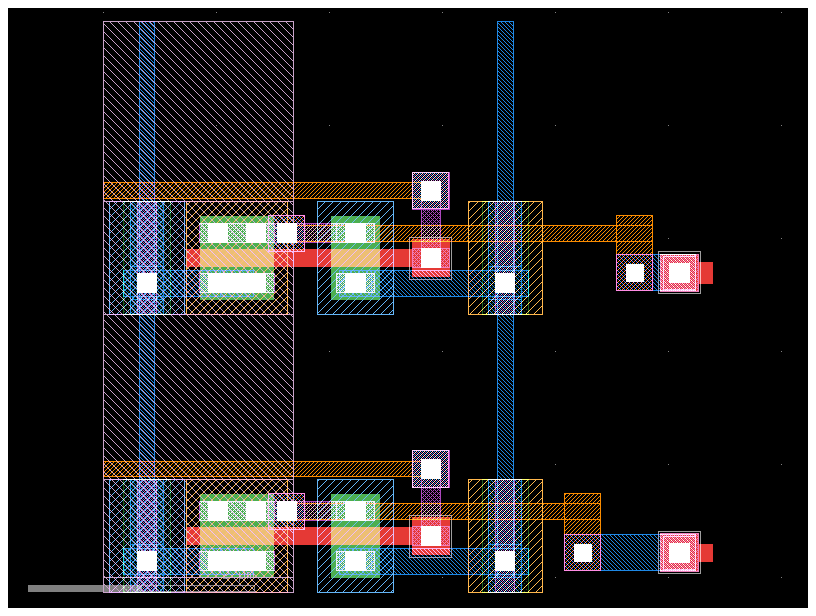

In [ ]:
from gc_compiler.periphery.wl_driver import (
    LEFT_WORDLINES,
    RIGHT_WORDLINES,
    wl_driver_pair,
    wordline_y,
)

ys = wordline_y(geo)
print("word lines of a mirrored row pair:")
for net, y in sorted(ys.items(), key=lambda kv: kv[1]):
    side = "left" if net in LEFT_WORDLINES else "right"
    print(f"  {net:6s} y={y:6.3f} um   landed from the {side}")
print(f"  closest pair: {min(b - a for a, b in zip(sorted(ys.values()), sorted(ys.values())[1:])):.3f} um apart")

wl_driver_pair(tech, geo, logic_cfg, LEFT_WORDLINES, name="nb_wl_driver").plot(show_labels=False)


### Column circuits

Each column gets the same three slices, rotated 90 degrees so their supply rails run
horizontally and their footprint matches the 1.22 um column pitch:

* a **precharge** PMOS that holds `rbl` high between reads,
* a **read buffer** - a plain inverter whose trip point turns the bit-line swing into a
  logic level on `dout`,
* a **write driver** that puts `din` on `wbl`.

These are the slices of the plain configuration used here. The default macro (section 21) writes a
refresh back inside the column: its write driver is a fourth slice, `wbl = NAND(din, rbl)`, so with
`din` high it puts the column's own sensed bit back on `wbl`.

A gain cell needs no write-enable gating in the column: `wbl` can be driven all the time
because the cell only samples it while `wwl` is asserted. That is one of the quiet
advantages of the two-ported topology.


column strip: 1.22 x 12.84 um (pitch matches the bitcell)
  din track x=0.995, dout track x=0.340


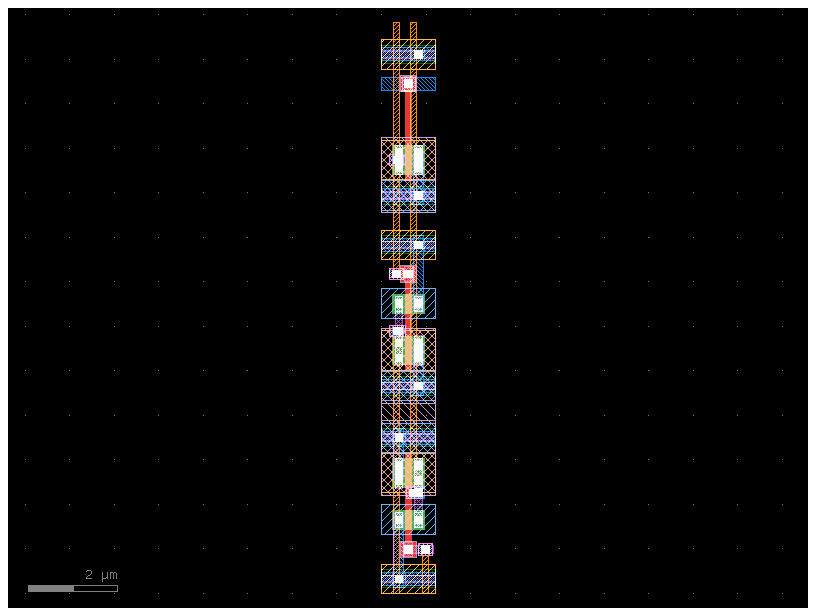

In [ ]:
from gc_compiler.periphery.column import column_circuit, column_geometry

col_geo = column_geometry(tech, geo, LogicConfig(pitch=geo.pitch_x))
print(f"column strip: {col_geo.width:.2f} x {col_geo.height:.2f} um (pitch matches the bitcell)")
print(f"  din track x={col_geo.din_x:.3f}, dout track x={col_geo.dout_x:.3f}")
column_circuit(tech, geo, logic_cfg, name="nb_column").plot(show_labels=False)


### The assembled macro

The floorplan puts the array in the middle, a driver strip on each side and the column
circuits underneath, and runs continuous supply rails over the driver taps so the strips
stay connected across the array's tap rows.

This macro takes the raw per-row `wwl_in`/`rwl_in` inputs. Section 13 adds the address
decoders (`decoded=True`) and shows the full macro, verified with LVS.


In [ ]:
macro_result = GainCellCompiler(ArrayConfig.basic(rows=8, cols=8), tech).build(
    "build", name="nb_macro_8x8", decoded=False
)
print(macro_result)
for key in (
    "macro_width_um",
    "macro_height_um",
    "macro_area_per_bit_um2",
    "macro_efficiency",
    "driver_width_um",
    "column_height_um",
    "transistors",
):
    print(f"{key:>24}: {macro_result.metrics[key]}")
print(run_drc(macro_result.gds))


nb_macro_8x8: 8x8 = 64 bits, 23.25 x 37.65 um, 13.678 um2/bit
          macro_width_um: 23.25
         macro_height_um: 37.65
  macro_area_per_bit_um2: 13.6775390625
        macro_efficiency: 0.21942543803281497
         driver_width_um: 5.39
        column_height_um: 12.84
             transistors: 264


DRC clean: nb_macro_8x8.gds


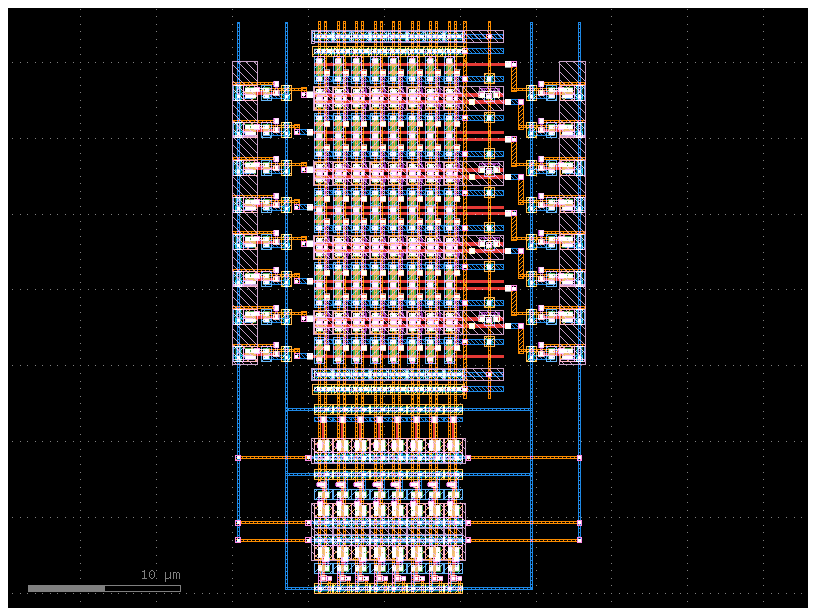

In [ ]:
macro_result.component.plot(show_labels=False)


In [ ]:
from gc_compiler.netlist import macro_netlist

lines = macro_netlist(tech, ArrayConfig.basic(rows=2, cols=2), logic_cfg).splitlines()
start = lines.index(next(line for line in lines if line.startswith(".subckt gc_inv")))
print("\n".join(lines[start:]))


.subckt gc_inv a y vdd vss
Xmp y a vdd vdd sky130_fd_pr__pfet_01v8 w=0.64 l=0.15
Xmn y a vss vss sky130_fd_pr__nfet_01v8 w=0.42 l=0.15
.ends

.subckt gc_nand2 a b y vdd vss
Xmpa y a vdd vdd sky130_fd_pr__pfet_01v8 w=0.64 l=0.15
Xmpb y b vdd vdd sky130_fd_pr__pfet_01v8 w=0.64 l=0.15
Xmna y a mid vss sky130_fd_pr__nfet_01v8 w=0.42 l=0.15
Xmnb mid b vss vss sky130_fd_pr__nfet_01v8 w=0.42 l=0.15
.ends

.subckt gc_nand3 a b c y vdd vss
Xmpa y a vdd vdd sky130_fd_pr__pfet_01v8 w=0.64 l=0.15
Xmpb y b vdd vdd sky130_fd_pr__pfet_01v8 w=0.64 l=0.15
Xmpc y c vdd vdd sky130_fd_pr__pfet_01v8 w=0.64 l=0.15
Xmna y a mid1 vss sky130_fd_pr__nfet_01v8 w=0.42 l=0.15
Xmnb mid1 b mid2 vss sky130_fd_pr__nfet_01v8 w=0.42 l=0.15
Xmnc mid2 c vss vss sky130_fd_pr__nfet_01v8 w=0.42 l=0.15
.ends

.subckt gc_nor2 a b y vdd vss
Xmpa y a mid vdd sky130_fd_pr__pfet_01v8 w=0.64 l=0.15
Xmpb mid b vdd vdd sky130_fd_pr__pfet_01v8 w=0.64 l=0.15
Xmna y a vss vss sky130_fd_pr__nfet_01v8 w=0.42 l=0.15
Xmnb y b vss vss sky130

The 8x8 macro above spends most of its area on periphery: two 5.4 um driver strips and a
12.8 um column strip wrapped around a 9.8 x 23.2 um array. That overhead is fixed per row
and per column, so it amortises quickly with array size.


In [ ]:
print(f"{'macro':>10} {'width':>9} {'height':>9} {'um2/bit':>9} {'efficiency':>11}")
for rows, cols in ((16, 16), (32, 32), (64, 64), (128, 128), (256, 256)):
    m = GainCellCompiler(ArrayConfig.basic(rows=rows, cols=cols), tech).metrics(macro=True)
    print(
        f"{rows:>4}x{cols:<5} {m['macro_width_um']:9.1f} {m['macro_height_um']:9.1f} "
        f"{m['macro_area_per_bit_um2']:9.3f} {m['macro_efficiency']:10.1%}"
    )


     macro     width    height   um2/bit  efficiency
  16x16         35.7      59.9     8.357      35.9%
  32x32         57.9     104.4     5.907      50.8%
  64x64        102.4     193.4     4.835      62.1%
 128x128       191.3     371.3     4.336      69.2%
 256x256       369.2     727.2     4.097      73.3%


## 12. LVS: does the layout actually match the netlist?

DRC only checks geometry; it has no idea whether two wires are supposed to be the same
net. **LVS (layout-vs-schematic)** extracts a netlist straight from the GDS with `magic`
and compares it against the netlist the compiler generated, device by device and net by
net, using `netgen`'s graph-isomorphism engine.

Running it on the bare bitcell is exactly the case where it should - and does - find
something: `wwl`, `wbl`, `rwl` and `rbl` all match the reference netlist by name, but the
supply nets do not, because a single bitcell has no neighbour to tap its substrate or well
into. That is expected for an isolated cell; running LVS at the array level below shows
the same signals matching and narrows the mismatch down to something real.


In [ ]:
from gc_compiler.netlist import bitcell_subckt
from gc_compiler.verify import lvs_layout_vs_netlist
from pathlib import Path

lvs_dir = Path("build/lvs")
bitcell_gds = lvs_dir / "gc3t_lvs.gds"
bitcell_spice = lvs_dir / "gc3t_lvs.spice"
lvs_dir.mkdir(parents=True, exist_ok=True)
gain_cell_3t(tech, cell_cfg, name="gc3t_lvs").write_gds(bitcell_gds)
bitcell_spice.write_text(bitcell_subckt(tech, cell_cfg, name="gc3t"))

result = lvs_layout_vs_netlist(bitcell_gds, "gc3t_lvs", bitcell_spice, "gc3t", workdir=lvs_dir)
print(result)


LVS mismatch
  nets: layout=9 reference=8
  unmatched net: layout='vss' reference='vss'
  unmatched net: layout='VSUBS' reference=None


`wwl`/`wbl`/`rwl`/`rbl` are matched exactly by name (`nets: layout=9 reference=8`,
mismatches limited to `vss` and the well). Running the same check on a small tapped array
narrows it further: every device and every signal net matches, and only the supply
network is left open.


In [ ]:
from gc_compiler.array import gc_array
from gc_compiler.config import ArrayConfig
from gc_compiler.netlist import array_netlist

array_cfg = ArrayConfig.basic(rows=4, cols=4, tap_row_interval=1, strap_column_interval=0)
array_gds = lvs_dir / "gc_array_lvs.gds"
array_spice = lvs_dir / "gc_array_lvs.spice"
gc_array(tech, array_cfg, name="gc_array_lvs").write_gds(array_gds)
array_spice.write_text(array_netlist(tech, array_cfg, name="gc_array_lvs"))

array_result = lvs_layout_vs_netlist(
    array_gds, "gc_array_lvs", array_spice, "gc_array_lvs", workdir=lvs_dir
)
print(array_result)


LVS mismatch
  nets: layout=52 reference=50
  unmatched net: layout='w_n10_2343#' reference='vss'
  unmatched net: layout='w_n10_846#' reference=None
  unmatched net: layout='VSUBS' reference=None
  unmatched net: layout='/gc3t_w0.42x0.18_r0.42x0.15_pair_7//g' reference='gc3t:bit_3_3/n_int'
  unmatched net: layout='/gc3t_w0.42x0.18_r0.42x0.15_pair_7//g' reference='gc3t:bit_3_2/n_int'
  unmatched net: layout='/gc3t_w0.42x0.18_r0.42x0.15_pair_6//g' reference='gc3t:bit_3_1/n_int'
  unmatched net: layout='/gc3t_w0.42x0.18_r0.42x0.15_pair_6//g' reference='gc3t:bit_3_0/n_int'
  unmatched net: layout='/gc3t_w0.42x0.18_r0.42x0.15_pair_5//g' reference='gc3t:bit_2_3/n_int'
  unmatched net: layout='/gc3t_w0.42x0.18_r0.42x0.15_pair_5//g' reference='gc3t:bit_2_2/n_int'
  unmatched net: layout='/gc3t_w0.42x0.18_r0.42x0.15_pair_4//g' reference='gc3t:bit_2_1/n_int'
  unmatched net: layout='/gc3t_w0.42x0.18_r0.42x0.15_pair_4//g' reference='gc3t:bit_2_0/n_int'
  unmatched net: layout='/gc3t_w0.42x0.18_r

## 13. Address decoding

The word-line drivers expose `wwl_in_r` and `rwl_in_r`. The static decoder is built so its
row gates can sit at the word-line pitch: every output is **one 2-input NAND** (plus an
inverter for the write rows). The address is split into a low and a high part, each
predecoded to one-hot *bus lines* that run past every row -- `L` lines from the low bits,
and `H` lines from the high bits already ANDed with the enable (one set with `we`, one
with `re`). A predecoded line is one NOR over the bits' *complement* literals, so it comes
straight out of a gate. Row `r` is `NAND(L[low(r)], H[high(r)])`.

Both drivers invert their inputs, but the bitcell's write device is PMOS and its read
select is NMOS. Therefore the decoder produces:

- `wwl_in_r = select_r AND we`: the driver makes the selected write word line **low**.
- `rwl_in_r = NOT(select_r AND re)`: the driver makes the selected read word line **high**.

Idle enables and out-of-range addresses leave all word lines inactive. Tests exercise both
the decoder and the actual driver instances, not only the isolated decoder outputs.

Physically, the row cells sit at the driver inputs, so everything between a row cell and
its driver is a straight (or lightly jogged) metal2 wire. The predecode lines are metal1
tracks in the channel above the rows -- routing channels have no metal1 in them, so nothing
needs metal3 -- fed by metal2 stubs. The write inverters sit flipped under the NAND strip so
that the two share one vdd rail. Pin access accounts for lower-layer via pads as well as the
upper routing wires: DRC alone cannot detect a wrong-net short.

This standalone decoder is what `gc_macro(..., decoded=True)` places on each side of the array.

In [ ]:
from gc_compiler.netlist.decoder import address_bits, row_decoder_subckt

decoder_cfg = ArrayConfig.basic(rows=8, cols=4)
bits = address_bits(decoder_cfg.rows)
print(f"{decoder_cfg.rows} rows -> {bits} address bits")
print(row_decoder_subckt(tech, decoder_cfg, logic_cfg)[:900], "...")


8 rows -> 3 address bits
.subckt gc_row_decoder addr_0 addr_1 addr_2 we re wwl_in_0 rwl_in_0 wwl_in_1 rwl_in_1 wwl_in_2 rwl_in_2 wwl_in_3 rwl_in_3 wwl_in_4 rwl_in_4 wwl_in_5 rwl_in_5 wwl_in_6 rwl_in_6 wwl_in_7 rwl_in_7 vdd vss
* predecode lines (low bits: L, high bits with enable: H), then one NAND per row
Xnor3_0 addr_0 addr_1 addr_2 and_addr_0_n_addr_1_n_addr_2_n vdd vss gc_nor3
Xnand_1 and_addr_0_n_addr_1_n_addr_2_n we write_n_0 vdd vss gc_nand2
Xinv_2 write_n_0 wwl_in_0 vdd vss gc_inv
Xnand_3 and_addr_0_n_addr_1_n_addr_2_n re rwl_in_0 vdd vss gc_nand2
Xinv_4 addr_0 addr_0_n vdd vss gc_inv
Xnor3_5 addr_0_n addr_1 addr_2 and_addr_0_addr_1_n_addr_2_n vdd vss gc_nor3
Xnand_6 and_addr_0_addr_1_n_addr_2_n we write_n_1 vdd vss gc_nand2
Xinv_7 write_n_1 wwl_in_1 vdd vss gc_inv
Xnand_8 and_addr_0_addr_1_n_addr_2_n re rwl_in_1 vdd vss gc_nand2
Xinv_9 addr_1 addr_1_n vdd vss gc_inv
Xnor3_10 addr_0 addr_1_n addr_2 and_a ...


The tests simulate both the schematic and physical gate plan over every address and
all four `we`/`re` combinations, for full and half-decoders through 64 rows and a
non-power-of-two case. They also check the inverting drivers' output polarities.
Four-row Sky130 ngspice operating-point tests confirm the decoder output voltage levels.
These are static checks, not delay or address-transition glitch characterization.

The first cell below checks an 8-row decoder with its drivers. The next builds and plots
the **standalone** physical decoder, writes GDS/SPICE/PNG under `build/decoder`, and runs
DRC and LVS. LVS uses the existing parasitic-device filter; the reported port-list warning
is retained. Layout dimensions include all routing, including the lower tie channel.
Automated physical regressions cover full 2/4/32-row and half 8/16-row decoders.

In [ ]:
def simulate(subckt_text, known):
    """Evaluate a flat netlist of gc_inv/gc_nand*/gc_nor* instances (digital only, no timing)."""
    lines = [
        line.strip()
        for line in subckt_text.splitlines()
        if line.strip() and not line.strip().startswith(("*", ".subckt", ".ends"))
    ]
    instances = [(line.split()[-1], line.split()[1:-1]) for line in lines]
    values = dict(known)
    values["vdd"], values["vss"] = 1, 0
    changed = True
    while changed:
        changed = False
        for kind, nets in instances:
            if kind == "gc_inv":
                input_net, output_net, _vdd, _vss = nets
                if input_net in values and output_net not in values:
                    values[output_net] = 1 - values[input_net]
                    changed = True
            elif kind.startswith(("gc_nand", "gc_nor")):
                *inputs, output_net, _vdd, _vss = nets
                if all(net in values for net in inputs) and output_net not in values:
                    high = all if kind.startswith("gc_nand") else any
                    values[output_net] = int(not high(values[net] for net in inputs))
                    changed = True
    return values


from gc_compiler.netlist.spice import macro_subckt

subckt = row_decoder_subckt(tech, decoder_cfg, logic_cfg)
drivers = macro_subckt(tech, decoder_cfg, logic_cfg, "macro", "array", decoded=False)
for address in range(1 << bits):
    addr = {f"addr_{bit}": (address >> bit) & 1 for bit in range(bits)}
    for write_enable, read_enable in ((0, 0), (1, 0), (0, 1), (1, 1)):
        out = simulate(subckt + "\n" + drivers, {**addr, "we": write_enable, "re": read_enable})
        active_write = [row for row in range(decoder_cfg.rows) if out[f"wwl_{row}"] == 0]
        active_read = [row for row in range(decoder_cfg.rows) if out[f"rwl_{row}"] == 1]
        assert active_write == ([address] if write_enable and address < decoder_cfg.rows else [])
        assert active_read == ([address] if read_enable and address < decoder_cfg.rows else [])
print(f"All {decoder_cfg.rows} addresses and four enable states have correct word-line polarity.")

All 8 addresses and four enable states have correct word-line polarity.


DRC clean: row_decoder_8.gds
LVS match (unverified pins: wwl_in_7, addr_0, addr_1, addr_2, we, re, wwl_in_0, rwl_in_0, wwl_in_1, rwl_in_1, wwl_in_2, rwl_in_2, wwl_in_3, rwl_in_3, wwl_in_4, rwl_in_4, wwl_in_5, rwl_in_5, wwl_in_6, rwl_in_6, rwl_in_7, vdd, vss)
Port list unverified: True
GDS: gc_compiler/notebooks/build/decoder/row_decoder_8.gds
SPICE: gc_compiler/notebooks/build/decoder/row_decoder_8.spice
Bounds: 42.36 x 17.92 um
Gates: 35 tracks: 19


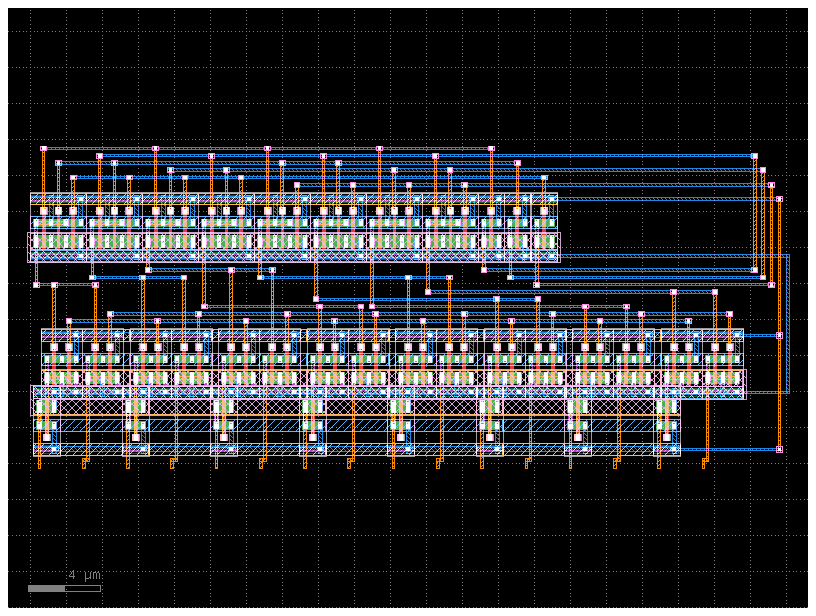

In [ ]:
from pathlib import Path

from gc_compiler.netlist.decoder import gate_subckts
from gc_compiler.netlist.spice import inverter_subckt
from gc_compiler.periphery.decoder import row_decoder
from gc_compiler.verify.drc import run_drc
from gc_compiler.verify.lvs import lvs_layout_vs_netlist

physical_decoder = row_decoder(tech, decoder_cfg, logic_cfg)
decoder_dir = Path("build/decoder").resolve()
decoder_dir.mkdir(parents=True, exist_ok=True)
decoder_gds = physical_decoder.write_gds(decoder_dir / "row_decoder_8.gds")
decoder_spice = decoder_dir / "row_decoder_8.spice"
decoder_spice.write_text("\n\n".join([
    inverter_subckt(tech, logic_cfg),
    *gate_subckts(tech, logic_cfg),
    row_decoder_subckt(tech, decoder_cfg, logic_cfg),
]))
decoder_drc = run_drc(decoder_gds)
decoder_lvs = lvs_layout_vs_netlist(
    decoder_gds, physical_decoder.name, decoder_spice, "gc_row_decoder",
    workdir=decoder_dir / "lvs",
)
assert decoder_drc.clean, str(decoder_drc)
assert decoder_lvs.matched, str(decoder_lvs)
print(decoder_drc)
print(decoder_lvs)
print("Port list unverified:", decoder_lvs.port_errors)
print("GDS:", decoder_gds)
print("SPICE:", decoder_spice)
print(f"Bounds: {physical_decoder.info['width']:.2f} x {physical_decoder.info['height']:.2f} um")
print("Gates:", physical_decoder.info["gate_count"], "tracks:", physical_decoder.info["track_count"])
physical_decoder.plot(show_labels=False)
plt.gcf().savefig(decoder_dir / "row_decoder_8.png", dpi=140, bbox_inches="tight")

### Decoders in the macro

`gc_macro(..., decoded=True)` places a half-decoder beyond each word-line driver column and
routes its outputs to the driver inputs; the macro then takes `addr_i`/`we`/`re` instead of
the raw per-row `wwl_in_r`/`rwl_in_r`. `GainCellCompiler.build()` now builds this decoded macro by
default (two banks of it, section 18; `banked=False` for one, `decoded=False` for the raw word-line
inputs) and writes the matching decoder-driven netlist. Because the row cells sit at the driver inputs, a 32x32 macro with decoders is about
119 x 110 um (24% array efficiency, against 51% without them).

Wiring the whole macro up exposed bugs that DRC could not see, because the offending shapes
merge into one polygon: the driver slices' and the column circuits' gate contacts overlapped
the inverter's own vss stub (every driver input, `din` and `rbl` were shorted to vss); the
column circuits were placed at a uniform pitch although the array shifts its columns past each
strap column; and vdd was never distributed. All three are fixed, and macro-level LVS -- array,
drivers, column circuits and decoders against `macro_netlist` -- now passes.

In [ ]:
from gc_compiler.array.floorplan import macro_geometry

# 24 columns: past the first strap column, where the array shifts its columns and the column
# circuits have to follow (a bug that only shows above 16 columns).
decoded_cfg = ArrayConfig.basic(rows=16, cols=24)
decoded_result = GainCellCompiler(decoded_cfg, tech).build(
    "build", name="nb_macro_16x24_decoded", banked=False
)
bare = macro_geometry(tech, decoded_cfg, logic_cfg)  # array + drivers + column circuits only
print(decoded_result)
print(f"without decoders: {bare.width:.1f} x {bare.height:.1f} um, "
      f"{bare.efficiency:.0%} array efficiency")
print(f"with decoders:    {decoded_result.metrics['macro_width_um']:.1f} x "
      f"{decoded_result.metrics['macro_height_um']:.1f} um, "
      f"{decoded_result.metrics['macro_efficiency']:.0%} array efficiency")
print("ports:", sorted(p.name for p in decoded_result.component.ports
                       if not p.name.startswith(("din_", "dout_")))[:12], "...")
decoded_drc = run_drc(decoded_result.gds)
print(decoded_drc)
assert decoded_drc.clean, str(decoded_drc)

nb_macro_16x24_decoded: 16x24 = 384 bits, 98.36 x 64.65 um, 16.559 um2/bit
without decoders: 45.5 x 59.9 um, 42% array efficiency
with decoders:    98.4 x 64.7 um, 18% array efficiency
ports: ['addr_0', 'addr_1', 'addr_2', 'addr_3', 'pch', 're', 'vdd', 'vss', 'we'] ...


DRC clean: nb_macro_16x24_decoded.gds


In [ ]:
# Layout vs. schematic for the whole macro: array, word-line drivers, column circuits and both
# decoders, extracted with magic and compared with netgen against the decoder-driven netlist.
decoded_lvs = lvs_layout_vs_netlist(
    decoded_result.gds, decoded_result.component.name, decoded_result.spice,
    decoded_result.component.name, workdir=Path("build/lvs_decoded_macro").resolve(),
)
print(decoded_lvs)
print("nets (layout, reference):", decoded_lvs.net_count)
print("unmatched nets:", decoded_lvs.mismatched_nets)
print("Port list unverified:", decoded_lvs.port_errors)
assert decoded_lvs.matched and not decoded_lvs.mismatched_nets, str(decoded_lvs)

LVS match (unverified pins: addr_0, addr_1, addr_2, addr_3, we, re, din_0, din_1, din_2, din_3, din_4, din_5, din_6, din_7, din_8, din_9, din_10, din_11, din_12, din_13, din_14, din_15, din_16, din_17, din_18, din_19, din_20, din_21, din_22, din_23, dout_0, dout_1, dout_2, dout_3, dout_4, dout_5, dout_6, dout_7, dout_8, dout_9, dout_10, dout_11, dout_12, dout_13, dout_14, dout_15, dout_16, dout_17, dout_18, dout_19, dout_20, dout_21, dout_22, dout_23, pch, vdd, vss, vnw)
nets (layout, reference): (1062, 1062)
unmatched nets: []
Port list unverified: True


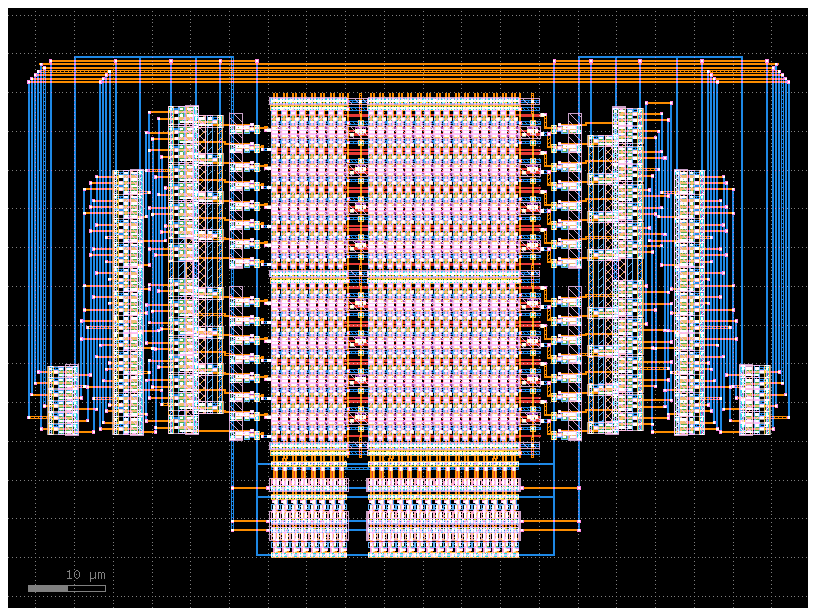

In [ ]:
decoded_result.component.plot(show_labels=False)

The plot shows the two decoders as tall, narrow blocks either side of the driver columns, and
the shared `addr`/`we`/`re` wires and supply trunks running across the top. Each decoder is only
as wide (along the array) as the array is tall, because its row cells sit at the driver inputs;
what makes it deep is the predecode bus and literal routing channels. LVS passing here matters
more than DRC: this is the check that found the shorted driver and column-circuit inputs, the
misplaced column circuits and the undistributed vdd, none of which DRC can see.

## 14. A replica bit line, and timing

A gain-cell read is a race: the word line has to rise, the read pair has to pull the bit line
below the read buffer's threshold, and only then is `dout` valid. How long that takes depends on
the decoder, the driver, the word-line RC and the corner, so a fixed delay either wastes cycles
or fails in the slow corner. The standard answer (and the one Harel *et al.* use for gain-cell
eDRAM) is a **replica bit line**: a column whose cells always discharge on a read, so that its
read buffer fires exactly when a real column's data becomes valid.

`ArrayConfig(replica_column=True)` adds one. Its cells share every row's word lines with the
array, so a read through them sees the same decoder, driver and word-line delay; what differs is
that the storage node is tied to the write bit line (`gain_cell_3t(replica=True)`), and the
column's write driver is fed a constant so that bit line sits at vdd. The read buffer's output is
a new macro pin, **`rdy`**.

In [ ]:
replica_cfg = ArrayConfig.basic(rows=16, cols=20, replica_column=True)
replica_result = GainCellCompiler(replica_cfg, tech).build(
    "build", name="nb_macro_16x20_replica", banked=False
)
plain = GainCellCompiler(ArrayConfig.basic(rows=16, cols=20), tech).build(
    "build", name="nb_macro_16x20_plain", banked=False
)
print(replica_result)
extra = replica_result.metrics["macro_area_um2"] / plain.metrics["macro_area_um2"] - 1
print(f"the replica column costs {extra:.1%} of the macro area; "
      f"{replica_result.metrics['bits']} bits stored, {replica_cfg.total_cols} columns drawn")
print()
print(bitcell_subckt(tech, cell_cfg, replica=True))
print("rdy" in {p.name for p in replica_result.component.ports})

nb_macro_16x20_replica: 16x20 = 320 bits, 94.70 x 64.65 um, 19.131 um2/bit
the replica column costs 1.3% of the macro area; 320 bits stored, 21 columns drawn

.subckt gc3t_rep wwl wbl rwl rbl vss vnw
* mw: write transistor, wbl -> sn under wwl control
Xmw wbl wwl wbl vnw sky130_fd_pr__pfet_01v8 w=0.42 l=0.18
* mr: read transistor, gated by the storage node
Xmr n_int wbl vss vss sky130_fd_pr__nfet_01v8 w=0.42 l=0.15
* ms: read select
Xms rbl rwl n_int vss sky130_fd_pr__nfet_01v8 w=0.42 l=0.15
.ends
True


In [ ]:
# The replica adds a column, a cell type and a write-driver tie: check them the same way as
# everything else, DRC for the geometry and LVS for the connectivity.
replica_drc = run_drc(replica_result.gds)
print(replica_drc)
replica_lvs = lvs_layout_vs_netlist(
    replica_result.gds, replica_result.component.name, replica_result.spice,
    replica_result.component.name, workdir=Path("build/lvs_replica_macro").resolve(),
)
print(replica_lvs)
assert replica_drc.clean, str(replica_drc)
assert replica_lvs.matched and not replica_lvs.mismatched_nets, str(replica_lvs)

DRC clean: nb_macro_16x20_replica.gds


LVS match (unverified pins: addr_0, addr_1, addr_2, addr_3, we, re, din_0, din_1, din_2, din_3, din_4, din_5, din_6, din_7, din_8, din_9, din_10, din_11, din_12, din_13, din_14, din_15, din_16, din_17, din_18, din_19, dout_0, dout_1, dout_2, dout_3, dout_4, dout_5, dout_6, dout_7, dout_8, dout_9, dout_10, dout_11, dout_12, dout_13, dout_14, dout_15, dout_16, dout_17, dout_18, dout_19, rdy, pch, vdd, vss, vnw)


### Post-layout timing characterisation

`GainCellCompiler.characterise(result)` (CLI: `--characterise`) measures the
macro as drawn rather than as schematically intended (`verify/timing.py`):

1. magic extracts the GDS **with parasitic capacitance** into one flat SPICE netlist whose nets
   are named after the layout's labels;
2. the netlist is **reduced**: the decoders, drivers and column circuits stay, as do the cells of
   both end columns and the replica; every other column becomes a multiplied gate load on the
   word lines, which is all it does to an access elsewhere. Each word line is poly all the way
   across the array, so it becomes a distributed RC ladder (capacitance from extraction,
   resistance from the poly sheet resistance), driven from the end its driver is at;
3. ngspice runs a write and a set of reads at five process/voltage/temperature corners -- fresh
   '1', decayed '1' (70% level) and '0', in the nearest and farthest cell of the first and last
   rows -- and measures the time from the `re`/`we` edge to each stage.

ngspice needs ~40 s just to parse the full `sky130.lib.spice`, nearly all of it the resistor
models and the special-cell library this bench never touches; `Technology.model_header()` loads
only the MOSFET corner file, which gives identical waveforms in a fraction of a second, so the
whole sweep takes a few minutes.

In [ ]:
import time

t0 = time.time()
timing = GainCellCompiler(replica_cfg, tech).characterise(replica_result, workdir="build/timing_replica")
print(f"characterised in {time.time() - t0:.0f} s\n")
print(timing.table())
print()
print("dout/rdy per corner:", {k: round(v, 2) for k, v in timing.replica_ratios().items()})
print(f"recommended strobe: rdy delayed x{timing.recommended_margin():.2f}")

characterised in 157 s

| corner | access | write | precharge | '1' level | '0' level | '0' reads | '0' limit | rdy (near/far) | dout/rdy |
|---|---|---|---|---|---|---|---|---|---|
| tt_1.8V_25C | 1.02 | 0.14 | 0.68 | 1.80 | 0.69 | ok | 0.69 | 0.98 / 1.02 | 1.10 |
| ss_1.62V_125C | 1.87 | 0.24 | 1.05 | 1.62 | 0.63 | ok | 0.63 | 1.86 / 1.87 | 1.10 |
| ff_1.98V_-40C | 0.66 | 0.10 | 0.51 | 1.98 | 0.70 | ok | 0.70 | 0.59 / 0.65 | 1.14 |
| sf_1.8V_25C | 1.14 | 0.19 | 0.93 | 1.80 | 0.88 | FAIL | 0.85 | 1.10 / 1.13 | 1.07 |
| fs_1.8V_25C | 1.01 | 0.11 | 0.52 | 1.80 | 0.48 | ok | 0.48 | 0.97 / 1.02 | 1.14 |

dout/rdy per corner: {'tt_1.8V_25C': 1.1, 'ss_1.62V_125C': 1.1, 'ff_1.98V_-40C': 1.14, 'sf_1.8V_25C': 1.07, 'fs_1.8V_25C': 1.14}
recommended strobe: rdy delayed x1.14


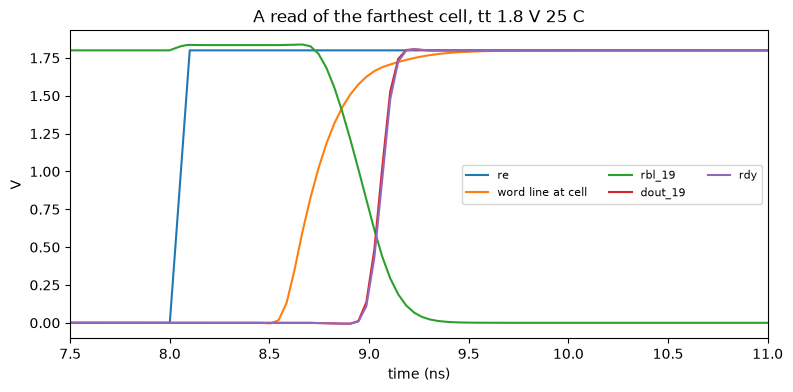

In [ ]:
# One read in the typical corner, straight from the simulator output: re rises, the decoder and
# driver raise the word line at the far cell, the bit line falls, and both the buffer of that
# column and the replica's fire.
import matplotlib.pyplot as plt
import numpy as np

wave = np.loadtxt("build/timing_replica/runs/tt_1.8V_25C/read1_r0_c19_l1/wave.csv")
names = ["re", "pch", "decoder out (active low)", "qvdd", "word line at cell", "rbl_19", "dout_19", "rdy"]
fig, ax = plt.subplots(figsize=(9, 4))
for i, name in enumerate(names):
    if name in ("pch", "decoder out (active low)", "qvdd"):
        continue
    ax.plot(wave[:, 2 * i] * 1e9, wave[:, 2 * i + 1], label=name)
ax.set_xlim(7.5, 11)
ax.set_xlabel("time (ns)")
ax.set_ylabel("V")
ax.legend(ncol=3, fontsize=8)
ax.set_title("A read of the farthest cell, tt 1.8 V 25 C")
plt.show()

What the table says:

* **`rdy` tracks the data.** The slowest legitimate read of a '1' is valid at 1.00-1.11x the
  replica's `rdy` time in every corner, while the access time itself swings 3x between ff and ss.
  Most of the ~1 ns access is the decoder (about 0.65 ns: this is the NOR3 predecode timing the
  previous section could not see) followed by the driver and the bit line, all of which the
  replica shares. A strobe of `rdy` plus ~15% covers every corner.
* **A written '0' is not readable.** This is the cost of the PMOS write port from section 9,
  now visible at macro level: with the write word line at vss a '0' settles at 0.5-0.9 V, above
  the read device's threshold, so the read returns a '1' in every corner but fs. The last
  column is the highest '0' level that still reads correctly; the write path has to reach
  0.3-0.5 V, which needs a word-line underdrive that the macro does not yet provide. The flow
  reports it as a FAIL instead of hiding it in a timing number. Section 15 builds that
  underdrive.

### Mismatch and Monte Carlo

The corners say how slow the slowest die is, not how far two neighbouring transistors of one die
differ -- and the difference is what limits a self-timed read: `rdy` comes from the replica's
read pair and the data from a real cell's. `verify/montecarlo.py` simulates **dies**: a seed that
(through `.option seed` and the PDK's `mc_mm_switch`) gives every transistor instance of the
reduced macro its own Gaussian offsets in `vth0`, `voff` and `toxe`, with the Pelgrom
`1/sqrt(W*L)` sigma. The same seed is the same silicon in every simulation, so a die is measured
once by a read (a decayed '1' at the far end of the word line and a '0' at the other end, in one
access) and once by a write.

Below: 24 dies at the typical corner, with each die's '0' starting from 0.2 V (what a write
underdrive would give: this macro's own write leaves 0.7 V, which fails every die) (the recorded 50-die, five-corner run is in the [README](https://github.com/barakhoffer/gc_compiler/blob/v1.0/README.md); the
CLI does it with `--monte-carlo 50`).

In [ ]:
from gc_compiler.verify.montecarlo import monte_carlo, table
from gc_compiler.verify.timing import build_model, standard_corners

mc_model = build_model(
    tech, replica_cfg, replica_result.gds, replica_result.component.name,
    "build/timing_replica/extract_mc",
)
t0 = time.time()
mc = monte_carlo(
    tech, mc_model, standard_corners()[0], 24, "build/timing_replica/mc_tt", seed=1, jobs=8,
    zero_level=0.2,  # this macro cannot write a readable '0'; 0.2 V is what an underdrive would give
)
print(f"{mc.n} dies ({mc.errors} failed runs) in {time.time() - t0:.0f} s\n")
print(table([mc]))
print()
print(f"the same seed is the same die: seed 1 gave dout at {mc.samples[0].read1.t_dout * 1e12:.1f} ps")
again = monte_carlo(
    tech, mc_model, standard_corners()[0], 1, "build/timing_replica/mc_tt_again", seed=1, jobs=1,
    zero_level=0.2,
)
print(f"                               re-simulated: {again.samples[0].read1.t_dout * 1e12:.1f} ps")
assert again.samples[0].read1.t_dout == mc.samples[0].read1.t_dout

24 dies (0 failed runs) in 51 s

| corner | dies | access (ns) | dout/rdy | 3σ strobe | strobe at | '1' fails | '0' flips at (x rdy) | '0' fails | '0' level (V) |
|---|---|---|---|---|---|---|---|---|---|
| tt_1.8V_25C | 24 | 1.06 ± 0.02 | 1.10 ± 0.02 | x1.15 | 8.8σ | 0/24 | - | 0/24 | 0.67 ± 0.03 |

the same seed is the same die: seed 1 gave dout at 1062.8 ps


                               re-simulated: 1062.8 ps


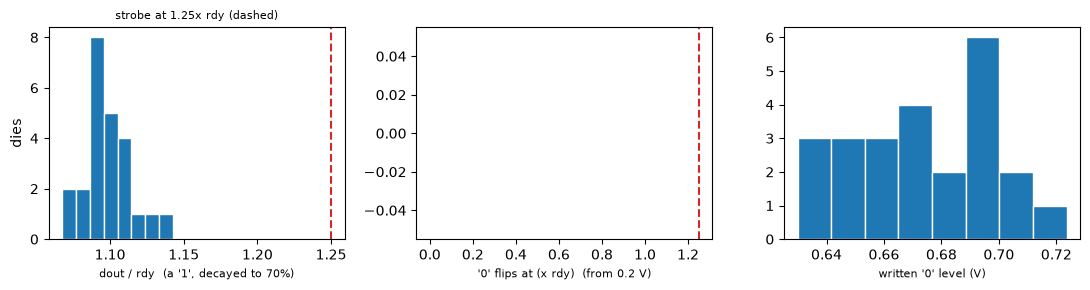

3-sigma margin from these dies: rdy delayed by x1.15; the strobe is 9 sigma beyond the mean tracking ratio


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, (values, label) in zip(
    axes,
    [
        ([s.tracking for s in mc.good], "dout / rdy  (a '1', decayed to 70%)"),
        ([s.flip for s in mc.good if s.flip], "'0' flips at (x rdy)  (from 0.2 V)"),
        ([s.write0.sn_final for s in mc.good], "written '0' level (V)"),
    ],
):
    ax.hist(values, bins=8, color="C0", edgecolor="white")
    ax.set_xlabel(label, fontsize=8)
axes[0].axvline(mc.strobe_factor, color="C3", ls="--")
axes[0].set_title(f"strobe at {mc.strobe_factor}x rdy (dashed)", fontsize=8)
axes[1].axvline(mc.strobe_factor, color="C3", ls="--")
axes[0].set_ylabel("dies")
plt.tight_layout()
plt.show()
print(f"3-sigma margin from these dies: rdy delayed by x{mc.margin(3.0):.2f}; "
      f"the strobe is {mc.sigma_to_strobe():.0f} sigma beyond the mean tracking ratio")

What the 50-die, five-corner run ([README](https://github.com/barakhoffer/gc_compiler/blob/v1.0/README.md)) shows:

| corner | dout/rdy | 3σ strobe | strobe at | '0' flips at (x rdy) |
|---|---|---|---|---|
| tt | 1.05 ± 0.02 | x1.09 | 13.2σ | 2.96 ± 0.43 |
| ss | 1.00 ± 0.02 | x1.05 | 15.1σ | 3.77 ± 0.59 |
| ff | 1.11 ± 0.02 | x1.16 | 9.0σ | 2.13 ± 0.14 |
| sf | 1.04 ± 0.01 | x1.08 | 15.5σ | 1.57 ± 0.08 |
| fs | 1.04 ± 0.02 | x1.09 | 11.8σ | 8.52 ± 1.29 |

* **Mismatch barely moves a '1' read.** The read and `rdy` are the same path built of the same
  devices, so a threshold shift that slows one slows the other: each varies by ~2% (1σ) from die
  to die, their ratio by 1-2%, and a 1.25x strobe is 9σ or more beyond the mean in every corner.
* **A '0' is where mismatch bites**, because it is read in subthreshold, where a millivolt of
  threshold is a few percent of current: its time-to-flip varies by 5-16%, and the tightest corner
  (sf) is only 4σ from the strobe.
* Local mismatch only: global variation is the corner sweep, and 50 dies bound a failure rate only
  below ~7%; the σ columns are Gaussian extrapolations, good to about 10%.

## 15. A negative write word line

Section 9 found that a PMOS write port cannot pull `sn` below about `|Vtp|`, and section 14 showed what
that means for the macro: with the write word line at vss a '0' settles at 0.5-0.9 V, above the read
device's threshold, and reads back as a '1' in every corner but fs. The fix that keeps the cell is to
drive `wwl` *below* vss. `ArrayConfig(negative_write_wl=True)` replaces each write driver with one that
swings between `vdd` and a new `vneg` supply.

A plain inverter cannot do it: with its NMOS source at `vneg` and its input low at 0 V, that NMOS has
`Vgs = |vneg|` and is never off. So a **level shifter** first moves the input into the `vdd`/`vneg`
domain -- PMOS inputs at the top rail (fully off at either rail), latched by two cross-coupled NMOS at
`vneg` -- and an inverter in that domain drives the word line: eight devices instead of two.

In [ ]:
from gc_compiler.netlist.spice import neg_driver_subckt
from gc_compiler.periphery.logic import LevelShifterConfig

print(neg_driver_subckt(tech, logic_cfg, LevelShifterConfig()))

.subckt gc_wwl_neg in wwl vdd vss vneg
Xinb in inb vdd vss gc_inv
* level shifter: PMOS inputs at vdd, latched by NMOS in an isolated well at vneg
Xpa x inb vdd vdd sky130_fd_pr__pfet_01v8 w=1.5 l=0.15
Xpb z in vdd vdd sky130_fd_pr__pfet_01v8 w=1.5 l=0.15
Xnx x z vneg vneg sky130_fd_pr__nfet_01v8 w=0.42 l=0.8
Xnz z x vneg vneg sky130_fd_pr__nfet_01v8 w=0.42 l=0.8
* output inverter in the vdd/vneg domain
Xpd wwl x vdd vdd sky130_fd_pr__pfet_01v8 w=0.64 l=0.15
Xnd wwl x vneg vneg sky130_fd_pr__nfet_01v8 w=0.42 l=0.15
.ends


Those NMOS need a body at `vneg`, which in sky130 means an **isolated p-well inside a deep n-well**: an
n-well ring around the p-type interior, the interior's tap being the `vneg` rail. The slice below is one
driver strip cell (a mirrored row pair): the standard column with the read inverter and the inverter that
makes `inb` at the left, the level shifter's PMOS well, the isolated well, the ring's right wall, and the
word-line landing against the array.

strip 19.40 um wide (the plain driver's: 5.39), 4.92 um per mirrored row pair
isolated p-well interior x = 10.28 .. 13.64 um, deep n-well 9.25 .. 14.67 um


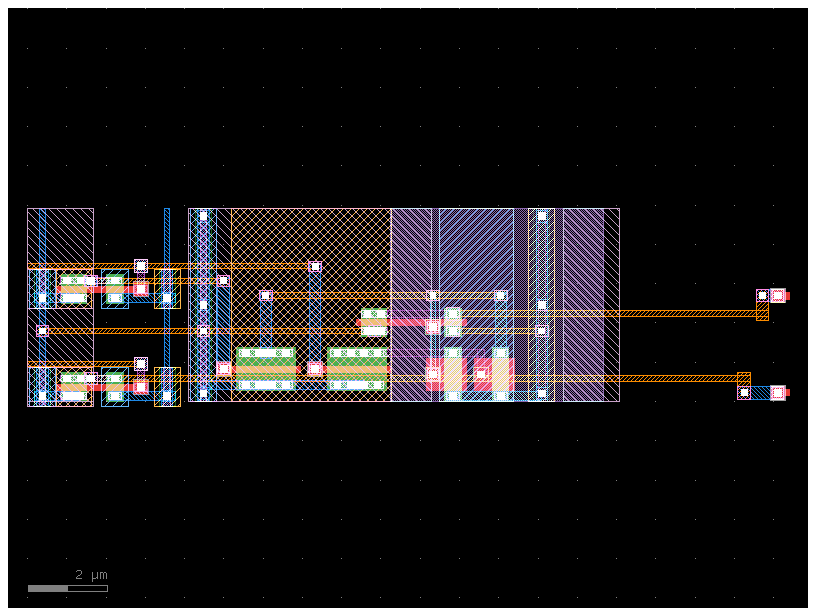

In [ ]:
from gc_compiler.periphery.wl_driver import LEFT_WORDLINES
from gc_compiler.periphery.wl_driver_neg import neg_driver_geometry, wl_driver_pair_neg
from gc_compiler.array import array_geometry

array_cell = array_geometry(tech, ArrayConfig.basic()).cell
neg_slice = wl_driver_pair_neg(tech, array_cell, logic_cfg, LevelShifterConfig(), LEFT_WORDLINES)
ng = neg_driver_geometry(tech, array_cell, logic_cfg, LevelShifterConfig())
print(f"strip {ng.width:.2f} um wide (the plain driver's: 5.39), {ng.height:.2f} um per mirrored row pair")
print(f"isolated p-well interior x = {ng.i0:.2f} .. {ng.i1:.2f} um, deep n-well {ng.i0 - 1.03:.2f} .. {ng.i1 + 1.03:.2f} um")
neg_slice.plot(show_labels=False)

Two rules shape it that the KLayout deck we sign off with does not have (magic's own deck does, and
[`tests/test_negative_wl.py`](https://github.com/barakhoffer/gc_compiler/blob/v1.0/tests/test_negative_wl.py) checks both geometrically): `dnwell.5` -- a deep n-well edge may not cut a P+
diffusion, so the level shifter's PMOS end left of it -- and `nwell.7` -- an n-well that does not overlap
the deep n-well stays 4.5 um from it, so the strip is wider than the devices need, to keep clear of the
array. Now the whole macro: DRC, and LVS against the netlist (which compares the isolated body too).

In [ ]:
neg_cfg = ArrayConfig.basic(rows=16, cols=20, replica_column=True, negative_write_wl=True)
neg_result = GainCellCompiler(neg_cfg, tech).build(
    "build", name="nb_macro_16x20_neg", banked=False
)
print(neg_result)
plain_area = replica_result.metrics["macro_area_um2"]
print(f"vs. the plain macro: {neg_result.metrics['macro_area_um2'] / plain_area - 1:+.0%} area; "
      f"write-word-line swing {neg_result.metrics['write_oxide_stress_v']:.1f} V across the oxide")
neg_drc = run_drc(neg_result.gds)
print(neg_drc)
neg_lvs = lvs_layout_vs_netlist(
    neg_result.gds, neg_result.component.name, neg_result.spice,
    neg_result.component.name, workdir=Path("build/lvs_neg_macro").resolve(),
)
print(neg_lvs, neg_lvs.net_count)
assert neg_drc.clean and neg_lvs.matched and not neg_lvs.mismatched_nets

nb_macro_16x20_neg: 16x20 = 320 bits, 122.72 x 64.65 um, 24.792 um2/bit
vs. the plain macro: +30% area; write-word-line swing 2.1 V across the oxide


DRC clean: nb_macro_16x20_neg.gds


LVS match (unverified pins: addr_0, addr_1, addr_2, addr_3, we, re, din_0, din_1, din_2, din_3, din_4, din_5, din_6, din_7, din_8, din_9, din_10, din_11, din_12, din_13, din_14, din_15, din_16, din_17, din_18, din_19, dout_0, dout_1, dout_2, dout_3, dout_4, dout_5, dout_6, dout_7, dout_8, dout_9, dout_10, dout_11, dout_12, dout_13, dout_14, dout_15, dout_16, dout_17, dout_18, dout_19, rdy, pch, vdd, vss, vnw, vneg) (986, 986)


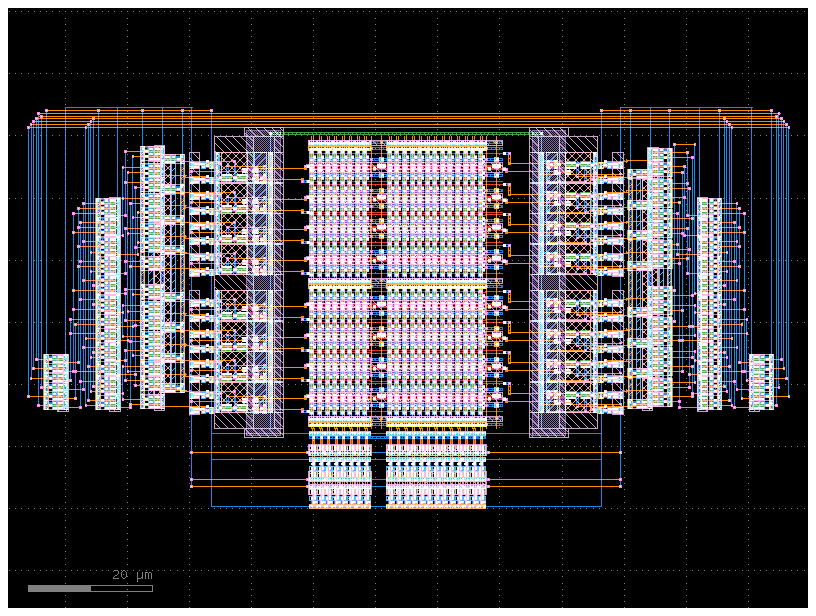

In [ ]:
neg_result.component.plot(show_labels=False)

**How negative?** The written '0' level is roughly `vneg + |Vtp|`, so it follows `vneg` -- but a corner
with a high `|Vtp|` needs more. The sweep below is on the extracted layout: write a '0' with `vneg` set to
each level, then read it back (correct = still a '0' when the data is sampled at 1.25x `rdy`; the number is
how long it survives, in units of `rdy` time).

In [ ]:
from concurrent.futures import ThreadPoolExecutor
from dataclasses import replace

from gc_compiler.verify.timing import (
    BenchSettings, build_model, simulate_reads, simulate_writes, standard_corners,
)

neg_model = build_model(
    tech, neg_cfg, neg_result.gds, neg_result.component.name, "build/timing_neg/extract"
)
corners = {c.process: c for c in standard_corners()}
levels = (-0.2, -0.3, -0.5, -0.8)


def sweep_point(arg):
    process, vneg = arg
    corner, s = corners[process], replace(BenchSettings(), vneg=vneg)
    base = f"build/timing_neg/sweep/{process}_{vneg}"
    w = simulate_writes(tech, neg_model, corner, 1, {"19": 1, "0": 0}, base + "_w", s)
    r = simulate_reads(
        tech, neg_model, corner, 1, {"0": (1, 0.7 * corner.vdd), "19": (0, w["0"].sn_final)}, base + "_r", s
    )
    z = r["19"]
    return w["0"].sn_final, z.correct, None if z.t_dout is None else z.t_dout / z.t_rdy


points = [(p, v) for v in levels for p in ("tt", "sf")]
with ThreadPoolExecutor(8) as pool:
    outcome = dict(zip(points, pool.map(sweep_point, points)))
print(f"{'vneg':>6} " + " ".join(f"{p:>22}" for p in ("tt", "sf")))
for v in levels:
    cellsx = []
    for p in ("tt", "sf"):
        sn0, ok, flip = outcome[(p, v)]
        cellsx.append(f"{sn0:5.2f} V {'ok  ' if ok else 'FAIL'} {'never' if flip is None else f'{flip:4.1f}x'}")
    print(f"{v:6.1f} " + " ".join(f"{c:>22}" for c in cellsx))

  vneg                     tt                     sf
  -0.2      0.51 V ok   never      0.71 V ok    1.7x
  -0.3      0.42 V ok   never      0.63 V ok    2.3x
  -0.5      0.25 V ok   never      0.46 V ok   never
  -0.8      0.01 V ok   never      0.20 V ok   never


The slow-PMOS/fast-NMOS corner (`sf`) is the one that sets the level. The default,
`write_wl_low = -0.3`, comes from a finer sweep of the same extracted macro ([README](https://github.com/barakhoffer/gc_compiler/blob/v1.0/README.md)): at `sf` a written
'0' already reads back from -0.2 V, -0.3 V leaves 0.23 V of margin, and going further buys little
retention (88 us worst die at -0.3 V, 122 us at -0.8 V) for more gate-oxide stress. The full characterisation of the extracted macro at all five corners:

In [ ]:
t0 = time.time()
neg_timing = GainCellCompiler(neg_cfg, tech).characterise(
    neg_result, workdir="build/timing_neg", monte_carlo=0
)
print(f"characterised in {time.time() - t0:.0f} s\n")
print(neg_timing.table())
print()
print(f"gate-oxide stress in a write: up to {neg_timing.write_stress():.2f} V "
      f"(vdd + |vneg|, at the ff supply)")
print(neg_timing.supply_table())

characterised in 143 s

| corner | access | write | precharge | '1' level | '0' level | '0' reads | '0' limit | rdy (near/far) | dout/rdy |
|---|---|---|---|---|---|---|---|---|---|
| tt_1.8V_25C | 1.04 | 0.13 | 0.69 | 1.80 | 0.43 | ok | 0.43 | 0.99 / 1.04 | 1.10 |
| ss_1.62V_125C | 1.90 | 0.20 | 1.06 | 1.62 | 0.38 | ok | 0.38 | 1.90 / 1.91 | 1.10 |
| ff_1.98V_-40C | 0.67 | 0.10 | 0.52 | 1.98 | 0.44 | ok | 0.44 | 0.60 / 0.67 | 1.15 |
| sf_1.8V_25C | 1.17 | 0.17 | 0.94 | 1.80 | 0.63 | ok | 0.63 | 1.12 / 1.15 | 1.07 |
| fs_1.8V_25C | 1.03 | 0.11 | 0.53 | 1.80 | 0.23 | ok | 0.23 | 0.99 / 1.04 | 1.15 |

gate-oxide stress in a write: up to 2.28 V (vdd + |vneg|, at the ff supply)
| corner | idle vdd (uA) | idle vneg (uA) | vneg peak in a write (uA) |
|---|---|---|---|
| tt_1.8V_25C | 0.0 | 0.0 | 305 |
| ss_1.62V_125C | 0.1 | 0.0 | 171 |
| ff_1.98V_-40C | 0.0 | 0.0 | 482 |
| sf_1.8V_25C | 0.0 | 0.0 | 289 |
| fs_1.8V_25C | 1.7 | 0.5 | 278 |


With mismatch on top: 16 dies at `sf`, the corner that sets `vneg`, each die's '0' starting from the level
its *own* write left (the default `mc_zero_level`; the recorded 50-die, five-corner run is in the [README](https://github.com/barakhoffer/gc_compiler/blob/v1.0/README.md)).

In [ ]:
from gc_compiler.verify.montecarlo import monte_carlo, table

t0 = time.time()
neg_mc = monte_carlo(tech, neg_model, corners["sf"], 16, "build/timing_neg/mc_sf", seed=1, jobs=8)
print(f"{neg_mc.n} dies ({neg_mc.errors} failed runs) in {time.time() - t0:.0f} s\n")
print(table([neg_mc]))
print(f"\nwritten '0' level: {neg_mc.sn_zero.mean:.2f} V mean, {neg_mc.sn_zero.maximum:.2f} V worst die")
print(f"'0' flips at {neg_mc.flip.mean:.2f} x rdy on average (earliest {neg_mc.flip.minimum:.2f}), "
      f"strobe at {neg_mc.strobe_factor} x rdy"
      if neg_mc.flip else "no '0' flips at all")
assert neg_mc.zero_failures == 0

16 dies (0 failed runs) in 45 s

| corner | dies | access (ns) | dout/rdy | 3σ strobe | strobe at | '1' fails | '0' flips at (x rdy) | '0' fails | '0' level (V) |
|---|---|---|---|---|---|---|---|---|---|
| sf_1.8V_25C | 16 | 1.17 ± 0.03 | 1.08 ± 0.01 | x1.11 | 15.0σ | 0/16 | 2.25 ± 0.29 | 0/16 | 0.63 ± 0.03 |

written '0' level: 0.63 V mean, 0.66 V worst die
'0' flips at 2.25 x rdy on average (earliest 1.86), strobe at 1.25 x rdy


* **A written '0' now reads back as a '0' in every corner** (0.00-0.20 V against 0.5-0.9 V), and a '1'
  still writes to the rail.
* **Reads are 2-3% slower** than the plain macro's (the strip is wider, so each read word line's route
  is longer; `rdy` tracks it). The **write path** is slower where the driver changed: decoder output to
  word line at the cell takes ~95 ps longer at tt, and the decoder ~30 ps more because it now drives the
  level shifter's input devices.
* **The supply**: the macro idles at ~1 uA on `vneg` (a level shifter whose inputs are fully off at both
  rails leaks like any logic gate; the first design, with NMOS inputs at `vneg`, burned 2-30 uA *per row*),
  and sees a peak of 0.25-0.6 mA in a write. Something has to generate `vneg`; that is not part of
  this compiler.
* **Costs**: the strip grows from 5.4 to 19.5 um per side, a fixed ~28 um of macro width (+30% area for
  16x20, +23% for 32x32, +15% for 64x64), and a write puts `vdd - write_wl_low` across the write device's
  and the output stage's gate oxide: 2.1 V at -0.3 V (2.28 V at the ff supply), 2.6 V at -0.8 V -- above
  the 1.8 V devices' rating, for the duration of a short pulse. That is a reliability question this
  flow does not answer.
* **Retention: refresh interval.** The numbers above only check that a '0' reads correctly right
  after a write, not how long it keeps reading correctly. `macro_refresh_interval` on the extracted
  macro ([README](https://github.com/barakhoffer/gc_compiler/blob/v1.0/README.md), [`measurements/data/`](https://github.com/barakhoffer/gc_compiler/tree/v1.0/measurements/data)): 122 us at the worst corner (ss, 125 C) with the rail at -0.8 V, and
  88 us for the worst of 20 mismatch dies at -0.3 V. That is shorter than section 16's LVT options
  despite a much bigger margin in volts (the '0' settles near 0 V here): this option keeps the plain
  cell's shorter, leakier write device, so the same kind of margin drains faster.


## 16. A supply-free alternative: LVT write + a longer read gate

The negative rail fixes a written '0', but it needs a pin something else has to supply. Section 9's
finding has another lever: the '0' a PMOS write leaves is about `|Vtp|` above its gate, and the read
device's own threshold sets how high a '0' it still calls a '0'. Both thresholds are ordinary
`BitcellConfig` fields -- `write_flavor` picks the write device's implant (`lvt` lowers `|Vtp|`,
so the write pulls lower), and `read_length` is the read gate's length (a longer NMOS has a higher
threshold, so it tolerates a higher '0'). Neither needs a new driver, a new supply, or a `pb` line --
just a different bitcell.

bitcell: 1.270 x 2.980 um (plain: 1.220 x 2.460)


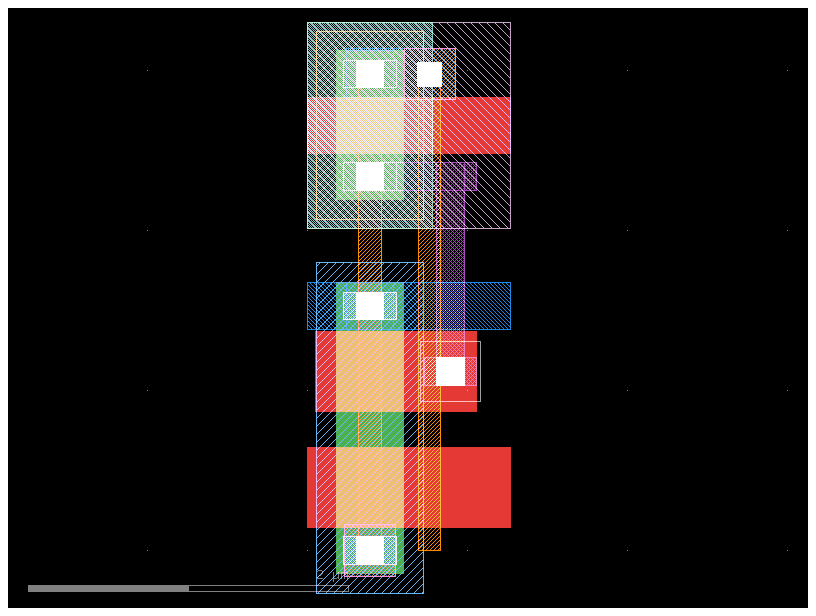

In [ ]:
from gc_compiler.config import BitcellConfig

lvt_bitcell = BitcellConfig.plain(write_flavor="lvt", write_length=0.35, read_length=0.5)
lvt_cell = gain_cell_3t(tech, lvt_bitcell)
print(f"bitcell: {lvt_cell.info['pitch_x']:.3f} x {lvt_cell.info['pitch_y']:.3f} um "
      f"(plain: {cell.info['pitch_x']:.3f} x {cell.info['pitch_y']:.3f})")
lvt_cell.plot(show_labels=False)

The cell grows a little in `x`: an LVT/HVT marker has its own enclosure of the diffusion it
covers, and where that is wider than the poly endcap the marker -- not the gate -- sets how close
the diffusion can sit to the cell edge (`diff_margin` in `cells/bitcell_3t.py`), so it never pokes
out of the n-well at the array's boundary. `write_length` also grows from 0.18 to 0.35 um (sky130's
LVT PMOS model is only characterised at `L >= 0.35`) and `read_length` from 0.15 to 0.5 um.

In [ ]:
lvt_cfg = ArrayConfig.basic(rows=16, cols=20, replica_column=True, bitcell=lvt_bitcell)
lvt_result = GainCellCompiler(lvt_cfg, tech).build(
    "build", name="nb_macro_16x20_lvt", banked=False
)
print(lvt_result)
print(f"vs. the plain macro: {lvt_result.metrics['macro_area_um2'] / plain_area - 1:+.0%} area")
lvt_drc = run_drc(lvt_result.gds)
print(lvt_drc)
lvt_lvs = lvs_layout_vs_netlist(
    lvt_result.gds, lvt_result.component.name, lvt_result.spice,
    lvt_result.component.name, workdir=Path("build/lvs_lvt_macro").resolve(),
)
print(lvt_lvs, lvt_lvs.net_count)
assert lvt_drc.clean and lvt_lvs.matched and not lvt_lvs.mismatched_nets

nb_macro_16x20_lvt: 16x20 = 320 bits, 95.75 x 72.97 um, 21.834 um2/bit
vs. the plain macro: +14% area


DRC clean: nb_macro_16x20_lvt.gds


LVS match (unverified pins: dout_7, addr_0, addr_1, addr_2, addr_3, we, re, din_0, din_1, din_2, din_3, din_4, din_5, din_6, din_7, din_8, din_9, din_10, din_11, din_12, din_13, din_14, din_15, din_16, din_17, din_18, din_19, dout_0, dout_1, dout_2, dout_3, dout_4, dout_5, dout_6, dout_8, dout_9, dout_10, dout_11, dout_12, dout_13, dout_14, dout_15, dout_16, dout_17, dout_18, dout_19, rdy, pch, vdd, vss, vnw) (937, 937)


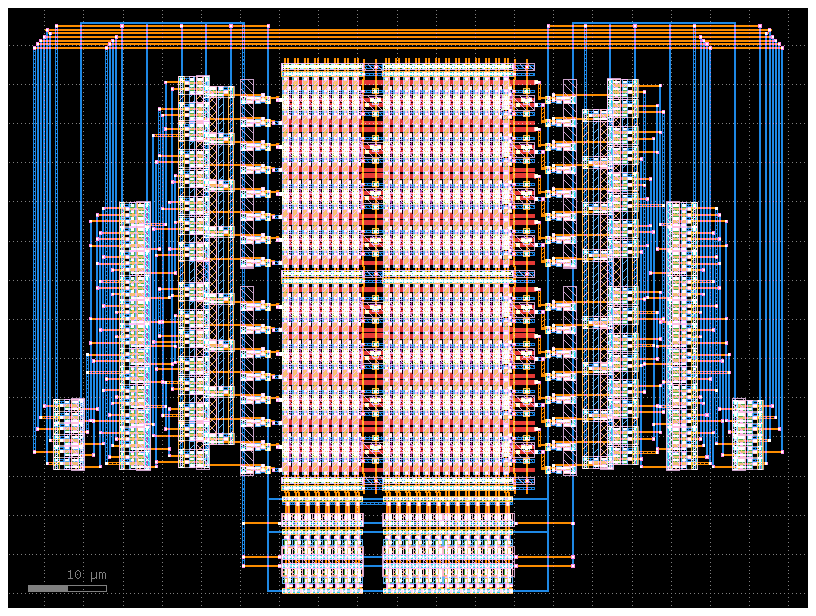

In [ ]:
lvt_result.component.plot(show_labels=False)

No level shifter, no isolated well, no extra pin -- the periphery is the plain driver's. The
full characterisation of the extracted macro at all five corners:

In [ ]:
t0 = time.time()
lvt_timing = GainCellCompiler(lvt_cfg, tech).characterise(
    lvt_result, workdir="build/timing_lvt", monte_carlo=0
)
print(f"characterised in {time.time() - t0:.0f} s\n")
print(lvt_timing.table())
print(f"\nvneg: {lvt_timing.vneg}  (no negative rail: nothing to report)")

characterised in 140 s

| corner | access | write | precharge | '1' level | '0' level | '0' reads | '0' limit | rdy (near/far) | dout/rdy |
|---|---|---|---|---|---|---|---|---|---|
| tt_1.8V_25C | 1.51 | 0.21 | 0.62 | 1.80 | 0.37 | ok | 0.37 | 1.49 / 1.53 | 1.07 |
| ss_1.62V_125C | 2.81 | 0.35 | 0.94 | 1.62 | 0.28 | ok | 0.28 | 2.73 / 2.85 | 1.09 |
| ff_1.98V_-40C | 0.98 | 0.14 | 0.49 | 1.98 | 0.41 | ok | 0.41 | 0.96 / 0.97 | 1.08 |
| sf_1.8V_25C | 1.81 | 0.29 | 0.87 | 1.80 | 0.50 | ok | 0.50 | 1.76 / 1.81 | 1.05 |
| fs_1.8V_25C | 1.44 | 0.14 | 0.44 | 1.80 | 0.24 | ok | 0.24 | 1.42 / 1.45 | 1.11 |

vneg: None  (no negative rail: nothing to report)


With mismatch on top: `sf` -- slow PMOS, fast NMOS -- is the tight corner, the same one that set
`vneg` for the negative-rail driver, because a slow PMOS writes a higher '0' and a fast NMOS reads a
lower one back. 16 dies there, each die's '0' starting from the level its *own* write left (the
recorded 50-die, five-corner run is in the [README](https://github.com/barakhoffer/gc_compiler/blob/v1.0/README.md)):

In [ ]:
lvt_model = build_model(
    tech, lvt_cfg, lvt_result.gds, lvt_result.component.name, "build/timing_lvt/extract"
)
t0 = time.time()
lvt_mc = monte_carlo(tech, lvt_model, corners["sf"], 16, "build/timing_lvt/mc_sf", seed=1, jobs=8)
print(f"{lvt_mc.n} dies ({lvt_mc.errors} failed runs) in {time.time() - t0:.0f} s\n")
print(table([lvt_mc]))
print(f"\nwritten '0' level: {lvt_mc.sn_zero.mean:.2f} V mean, {lvt_mc.sn_zero.maximum:.2f} V worst die")
print(f"'0' flips at {lvt_mc.flip.mean:.2f} x rdy on average (earliest {lvt_mc.flip.minimum:.2f}), "
      f"strobe at {lvt_mc.strobe_factor} x rdy"
      if lvt_mc.flip else "no '0' flips at all")
assert lvt_mc.zero_failures == 0

16 dies (0 failed runs) in 36 s

| corner | dies | access (ns) | dout/rdy | 3σ strobe | strobe at | '1' fails | '0' flips at (x rdy) | '0' fails | '0' level (V) |
|---|---|---|---|---|---|---|---|---|---|
| sf_1.8V_25C | 16 | 1.83 ± 0.04 | 1.04 ± 0.01 | x1.07 | 21.6σ | 0/16 | - | 0/16 | 0.50 ± 0.05 |

written '0' level: 0.50 V mean, 0.57 V worst die
no '0' flips at all


* **A written '0' reads back as a '0' in every corner, with no extra supply.** The read device's
  higher threshold and the write device's lower one meet with room to spare at tt/ss/ff/fs; `sf`
  -- both effects working against the margin at once -- is tightest, same as the negative rail.
* **Cost is a wider cell, not a wider driver.** The LVT marker's enclosure of the diffusion (not the
  poly endcap) sets the cell pitch, and the longer read gate needs more room along the same
  diffusion strip -- both grow the array, not the periphery, unlike the negative rail (which grows
  the driver strip and leaves the cell alone).
* **A longer read gate is not obviously worth it.** The same run at `read_length=1.0` ([README](https://github.com/barakhoffer/gc_compiler/blob/v1.0/README.md)): area
  +40% against +14% at 0.5, and access at tt about twice as long; the written '0' barely moves, since
  `read_length` does not touch the write path.
* **`read_length` was lengthening a device that did not need it.** The read side is `ms` (gated by
  `rwl`, the row select) and `mr` (gated by the storage node, the one whose threshold sets the
  tolerated '0') in series on one diffusion strip; `read_length` lengthens both, but only `mr`'s
  length matters for the '0' margin. `BitcellConfig.mr_length` overrides just `mr` -- next section.
* **Retention.** Measured on the extracted macro (`macro_refresh_interval`, [README](https://github.com/barakhoffer/gc_compiler/blob/v1.0/README.md)): the worst corner
  is ss at 125 C for every option, where the storage node's junction leaks most. This cell keeps
  617 us there (571 us for the worst of 20 mismatch dies), against the plain cell's 58 us (45 us).


## 17. The default cell: an LVT write and a longer `mr` only

Section 16 ended on `mr_length`: only the storage-node-gated device's threshold sets how high a '0'
still reads as one, so lengthen that one and leave `ms` -- the row-select device, whose length is also
the read word line's poly width -- alone. That is the compiler's default bitcell, `BitcellConfig()`:
an LVT write device of 0.35 um and a 0.5 um `mr` (`BitcellConfig.plain()` is the cell of sections 5-15).

BitcellConfig(write_kind=<DeviceKind.PMOS: 'pmos'>, read_kind=<DeviceKind.NMOS: 'nmos'>, write_width=0.42, write_length=0.35, read_width=0.42, read_length=0.15, mr_length=0.5, write_flavor='lvt', read_flavor=None, pitch_x=None)

                       plain: 1.220 x 2.460 um = 3.001 um2
 LVT, both read gates 0.5 um: 1.270 x 2.980 um = 3.785 um2
    LVT, mr 0.5 um (default): 1.270 x 2.630 um = 3.340 um2


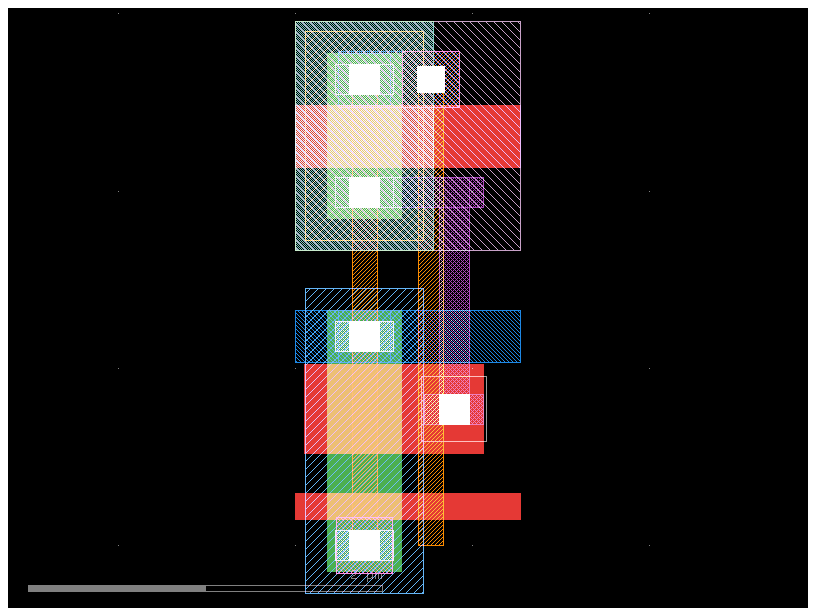

In [ ]:
default_bitcell = BitcellConfig()
print(default_bitcell)
print()
for label, bc in (
    ("plain", cell_cfg),
    ("LVT, both read gates 0.5 um", lvt_bitcell),
    ("LVT, mr 0.5 um (default)", default_bitcell),
):
    g = bitcell_geometry(tech, bc)
    print(f"{label:>28}: {g.pitch_x:.3f} x {g.pitch_y:.3f} um = {g.area:.3f} um2")
gain_cell_3t(tech, default_bitcell).plot(show_labels=False)

From the [README](https://github.com/barakhoffer/gc_compiler/blob/v1.0/README.md)'s characterisation of the three on the same extracted 16x20 macro: the macro is +5%
larger than the plain one (against +14% for both gates at 0.5 um), a read at tt is as fast as the
plain cell's (1.14 ns, against 1.52 ns), the '0' the read tolerates at `sf` rises from 0.86 to 1.03 V,
every one of 50 mismatch dies reads its '0' back at every corner, and the worst refresh interval is
703 us (614 us for the worst of 20 dies) -- twelve times the plain cell's.

## 18. Two banks around one decoder

A decoder column is as tall as the array, and most of its width is routing, not gates -- so share it.
`build(banked=True)`, the default for a decoded macro, places two banks of the array either side of
one central decoder; one more address bit picks the bank, and each bank keeps its own column circuits,
`din`/`dout` and `rdy`. The predecode sits in the middle and the far bank's word lines are reached on
metal3 over it.

nb_macro_16x20_banked: 2 banks of 16x20 = 640 bits, 165.46 x 61.43 um, 15.880 um2/bit
area per bit: one bank 19.13 um2, two banks 15.88 um2 (-17%)
pins: ['addr_0', 'addr_1', 'addr_2', 'addr_3', 'addr_4', 'pch', 'rdy_0', 'rdy_1', 're', 'vdd', 'vss', 'we']


DRC clean: nb_macro_16x20_banked.gds


LVS match (unverified pins: vnw_0, vnw_1) (1769, 1769)


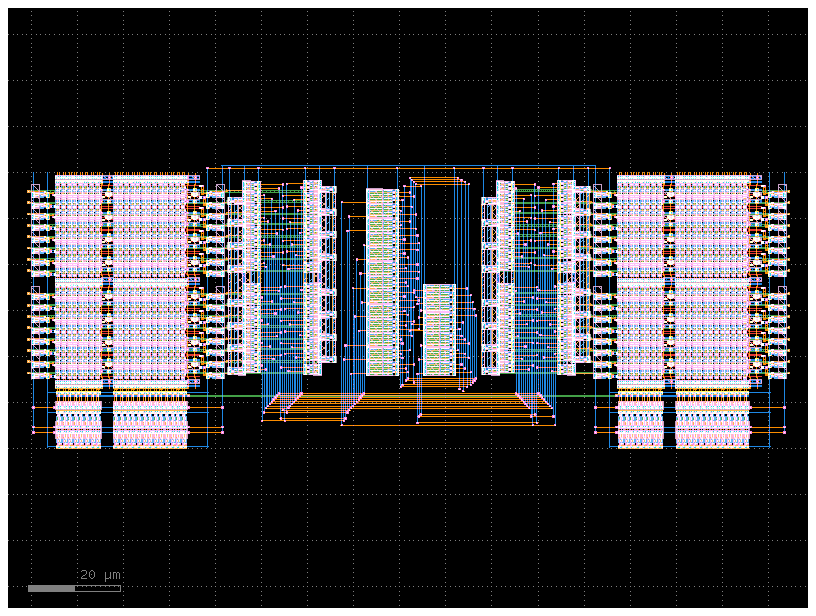

In [ ]:
banked_result = GainCellCompiler(replica_cfg, tech).build("build", name="nb_macro_16x20_banked", banked=True)
print(banked_result)
one = replica_result.metrics["macro_area_per_bit_um2"]
two = banked_result.metrics["macro_area_per_bit_um2"]
print(f"area per bit: one bank {one:.2f} um2, two banks {two:.2f} um2 ({two / one - 1:+.0%})")
print("pins:", sorted(p.name for p in banked_result.component.ports if not p.name.startswith(("din_", "dout_"))))

banked_drc = run_drc(banked_result.gds)
print(banked_drc)
banked_lvs = lvs_layout_vs_netlist(
    banked_result.gds, banked_result.component.name, banked_result.spice, banked_result.component.name,
    workdir=Path("build/lvs_banked_macro").resolve(),
    ports={p.name: tuple(p.dcenter) for p in banked_result.component.ports},
)
print(banked_lvs, banked_lvs.net_count)
assert banked_drc.clean and banked_lvs.matched and not banked_lvs.mismatched_nets
banked_result.component.plot(show_labels=False)

## 19. Wide arrays: word-line straps and stronger drivers

Word lines are poly, about 48 ohm per square, so on a wide array the far cell waits for an RC line.
`wordline_straps` runs a metal3 line over every word line, fed by its driver and tied down to the poly
in every strap column, so no stretch of poly is longer than 16 columns; `wordline_driver_strength`
scales the driver's devices (along the driver column, which gets wider, not taller). Both are on by
default from 64 columns (`config.WIDE_ARRAY`): measured on the extracted 16-row macro, a read at 64
columns goes from 1.78 to 1.09 ns, at 128 from 3.42 to 1.25 ns, for 2.6-4% of the decoded macro's
area ([README](https://github.com/barakhoffer/gc_compiler/blob/v1.0/README.md)). The table below is the array, drivers and column circuits only -- no decoder -- so
the same added driver width is a larger share of it.

  63 columns by default: straps False, drivers x1
  64 columns by default: straps True, drivers x4

  16 x  straps  drivers  width um  um2/bit
    32   False       1x      59.2     6.92
    32    True       4x      65.5     7.67
    64   False       1x     103.6     6.06
    64    True       4x     110.0     6.43
   128   False       1x     192.5     5.63
   128    True       4x     198.9     5.82


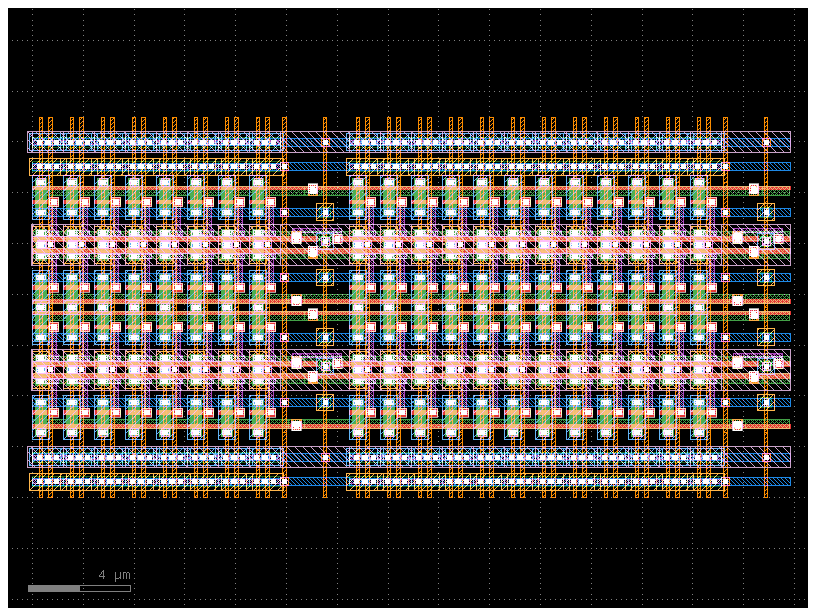

In [ ]:
from gc_compiler.config import WIDE_ARRAY

for cols in (WIDE_ARRAY - 1, WIDE_ARRAY):
    c = ArrayConfig(rows=16, cols=cols)
    print(f"{cols:4d} columns by default: straps {c.wordline_straps}, drivers x{c.wordline_driver_strength:g}")
print()
print(f"{'16 x':>6} {'straps':>7} {'drivers':>8} {'width um':>9} {'um2/bit':>8}")
for cols in (32, 64, 128):
    for straps, strength in ((False, 1.0), (True, 4.0)):
        c = ArrayConfig.basic(rows=16, cols=cols, replica_column=True,
                              wordline_straps=straps, wordline_driver_strength=strength)
        g = macro_geometry(tech, c, logic_cfg)
        print(f"{cols:6d} {str(straps):>7} {strength:7.0f}x {g.width:9.1f} {g.area / c.bits:8.2f}")

gc_array(tech, ArrayConfig.basic(rows=4, cols=20, wordline_straps=True), name="nb_array_straps").plot(show_labels=False)

The metal3 lines over each row pair, and the strap column where they drop to the poly, are what the
plot shows; the word lines' own poly is unchanged underneath.

## 20. Self-timed reads

Section 14's replica says when the data is there, and section 14's table says why a fixed read time
cannot serve every corner: the slow corner needs longer than the fast corner's stored '0' lasts
before its bit line drifts down too. With `self_timed_read` -- the default whenever there is a replica
column -- the replica's `rdy` becomes one more input of every read-enable line in the decoder (folded
into the NOR where it fits, gated once where it does not), so the read word line turns itself off one
decoder delay after `rdy`. `pch` is still up, so the bit lines -- and `dout` -- hold. However long `re`
stays high, each corner's read ends where its own replica says.

In [ ]:
from gc_compiler.netlist.decoder import decoder_inputs

st_cfg = ArrayConfig(rows=16, cols=20)  # the defaults: LVT cell, replica column, self-timed reads, in-macro refresh
print(f"replica {st_cfg.replica_column}, self-timed {st_cfg.self_timed_read}")
print("decoder inputs:", decoder_inputs(st_cfg, False))
st_result = GainCellCompiler(st_cfg, tech).build("build", name="nb_macro_16x20_st", banked=False)
fixed_result = GainCellCompiler(ArrayConfig(rows=16, cols=20, self_timed_read=False), tech).build(
    "build", name="nb_macro_16x20_fixed", banked=False
)
print(st_result)
cost = st_result.metrics["macro_area_um2"] / fixed_result.metrics["macro_area_um2"] - 1
print(f"self-timing costs {cost:+.1%} area (rdy's route round the macro, one more decoder input)")

st_drc = run_drc(st_result.gds)
print(st_drc)
st_lvs = lvs_layout_vs_netlist(
    st_result.gds, st_result.component.name, st_result.spice, st_result.component.name,
    workdir=Path("build/lvs_st_macro").resolve(),
    ports={p.name: tuple(p.dcenter) for p in st_result.component.ports},
)
print(st_lvs, st_lvs.net_count)
assert st_drc.clean and st_lvs.matched and not st_lvs.mismatched_nets

replica True, self-timed True
decoder inputs: ['addr_0', 'addr_1', 'addr_2', 'addr_3', 'we', 're', 'rdy']


nb_macro_16x20_st: 16x20 = 320 bits, 99.67 x 72.47 um, 22.572 um2/bit
self-timing costs +12.0% area (rdy's route round the macro, one more decoder input)


DRC clean: nb_macro_16x20_st.gds


LVS match (unverified pins: vnw) (962, 962)


On the extracted macro: write a '0' near the drivers, then read it together with a '1' at the far end,
holding `re` for the bench's whole 10 ns window -- two (ss) to eight (ff) times what a read needs. A read is right
if `dout` is still at the stored data when `re` finally falls.

In [ ]:
from gc_compiler.verify.timing import build_model, simulate_reads, simulate_writes, standard_corners

corners = {c.process: c for c in standard_corners()}
st_model = build_model(tech, st_cfg, st_result.gds, st_result.component.name, "build/timing_st/extract")
near, far = st_model.kept[0], st_model.kept[-1]
print(f"{'corner':>14} {'cell':>5} {'data':>5} {'rdy ns':>7} {'cutoff ns':>10} {'dout ns':>8} {'correct':>8}")
for process, corner in corners.items():
    written = simulate_writes(tech, st_model, corner, 0, {near: 0, far: 0}, f"build/timing_st/{process}_w")
    reads = simulate_reads(
        tech, st_model, corner, 0, {near: (0, written[near].sn_final), far: (1, corner.vdd)},
        f"build/timing_st/{process}_r",
    )
    for col, r in reads.items():
        ns = lambda t: "-" if t is None else f"{t * 1e9:.2f}"
        print(f"{corner.name:>14} {col:>5} {r.data:>5} {ns(r.t_rdy):>7} {ns(r.t_cutoff):>10} {ns(r.t_dout):>8} {str(r.correct):>8}")
    assert all(r.correct for r in reads.values())

        corner  cell  data  rdy ns  cutoff ns  dout ns  correct


   tt_1.8V_25C     0     0    1.82       2.26        -     True
   tt_1.8V_25C    19     1    1.82       2.34     1.33     True


 ss_1.62V_125C     0     0    3.49       4.40        -     True
 ss_1.62V_125C    19     1    3.49       4.48     2.52     True


 ff_1.98V_-40C     0     0    1.13       1.37        -     True
 ff_1.98V_-40C    19     1    1.13       1.45     0.83     True


   sf_1.8V_25C     0     0    2.07       2.44        -     True
   sf_1.8V_25C    19     1    2.07       2.52     1.49     True


   fs_1.8V_25C     0     0    1.82       2.34        -     True
   fs_1.8V_25C    19     1    1.82       2.42     1.32     True


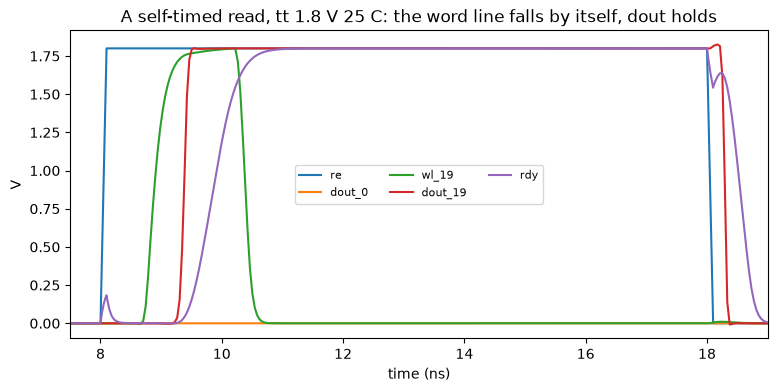

In [ ]:
# the tt read above, straight from the simulator: probes in the bench's order -- re, pch, decoder
# output, supply charge, then per cell its word line, read bit line and dout, then rdy
wave = np.loadtxt("build/timing_st/tt_r/wave.csv")
names = ["re", "pch", "dec", "qvdd"] + [f"{k}_{c}" for c in (near, far) for k in ("wl", "rbl", "dout")] + ["rdy"]
fig, ax = plt.subplots(figsize=(9, 4))
for i, name in enumerate(names):
    if name in ("re", f"wl_{far}", f"dout_{near}", f"dout_{far}", "rdy"):
        ax.plot(wave[:, 2 * i] * 1e9, wave[:, 2 * i + 1], label=name)
ax.set_xlim(7.5, 19)
ax.set_xlabel("time (ns)")
ax.set_ylabel("V")
ax.legend(ncol=3, fontsize=8)
ax.set_title("A self-timed read, tt 1.8 V 25 C: the word line falls by itself, dout holds")
plt.show()

The [README](https://github.com/barakhoffer/gc_compiler/blob/v1.0/README.md) has the mismatch run behind the default: with self-timed reads the LVT/`mr` macro reads
every one of 20 dies correctly at all five corners (the plain cell still fails at `sf`, where its own
written '0' is out of spec).

## 21. Refresh

A stored '0' leaks up, so every row has to be rewritten within the refresh interval. One ordinary
access does it, and the macro does the write-back itself: `re` and `pch` rise on the row; the
self-timed read ends by itself and, with `pch` still up, each read bit line holds the row's bit; the
controller drops `re` and pulses `we` with every `din` high -- each column's write driver is
`NAND(din, rbl)`, so it writes its own sensed bit back -- and `pch` falls a cycle after `we`. No data
leaves the macro, so no path through the controller has to be timed (`ArrayConfig.refresh_in_macro`,
the default with self-timed reads; `refresh_in_macro=False` or `--no-refresh-in-macro` loops the data
through the controller instead: `din = ~dout`, through an inverting write driver). Outside refreshes
`din` is low except in a user write, so a read leaves the write bit lines still.

`GainCellCompiler.refresh_rtl` writes the controller as synthesizable Verilog -- a request/busy user
interface, a row counter, a timer that spreads the rows evenly over half the interval -- plus a
behavioural model of the macro that loses a row not rewritten in time, a top level and a
self-checking testbench. The interval defaults to the one measured for the cell. The user side: a
request (`req`, `we`, `addr`, `din`) is taken on an edge where `busy` is low, and `we`, `addr` and
`din` must hold until `busy` is low again -- the controller keeps no copy of them; a read's data comes
with `dout_valid` and holds until the next read.

In [ ]:
import shutil
import subprocess

from gc_compiler.rtl import default_refresh_interval_us

print(f"refresh interval for this cell: {default_refresh_interval_us(st_cfg):g} us; "
      f"written back {'in the macro' if st_cfg.refresh_in_macro else 'through the controller'}")
rtl_paths = GainCellCompiler(st_cfg, tech).refresh_rtl(st_result, clock_ns=5.0)
for path in rtl_paths:
    print(" ", path)
ctrl = next(p for p in rtl_paths if p.name.endswith("_ctrl.v")).read_text()
print("\n".join(ctrl.splitlines()[:12]))

if shutil.which("iverilog"):
    vvp = rtl_paths[0].with_name("nb_refresh.vvp")
    subprocess.run(["iverilog", "-g2005", "-o", str(vvp), *(str(p) for p in rtl_paths if p.suffix == ".v")], check=True)
    sim = subprocess.run(["vvp", str(vvp)], capture_output=True, text=True, timeout=1800, check=True).stdout
    print("\n".join(sim.strip().splitlines()[-4:]))
    assert "PASS" in sim

refresh interval for this cell: 614 us; written back in the macro
  build/nb_macro_16x20_st_ctrl.v
  build/nb_macro_16x20_st_model.v
  build/nb_macro_16x20_st_top.v
  build/nb_macro_16x20_st_tb.v
  build/nb_macro_16x20_st_ctrl.sdc
// Refresh controller for nb_macro_16x20_st (generated by gc_compiler.rtl).
// Clock 5 ns; read 4 ns, write 2 ns,
// precharge 2 ns; every row refreshed within 0.5 x 614 us.
`timescale 1ns/1ps
module nb_macro_16x20_st_ctrl #(
    parameter ADDR_BITS = 4,
    parameter COLS = 20,
    parameter ROWS = 16,              // rows per bank
    parameter READ_CYCLES = 2,
    parameter WRITE_CYCLES = 1,
    parameter PRECHARGE_CYCLES = 1,
    parameter REFRESH_CYCLES = 3837


reads 5033 writes 5116 busy_max 11 errors 0
PASS
build/nb_macro_16x20_st_tb.v:73: $finish called at 1842515000 (1ps)


The testbench writes every row, runs random reads and writes against a golden copy for one interval,
then leaves the memory alone for two more: only refresh keeps the data, and with the timer disabled the
same bench fails ([`tests/test_refresh.py`](https://github.com/barakhoffer/gc_compiler/blob/v1.0/tests/test_refresh.py)). On the extracted macro, `verify.timing.simulate_refresh`
checks the access itself: decayed '1's (70% of vdd) and '0's at the read limit come back at every corner,
and under 20 local-mismatch dies at ss ([`measurements/data/refresh_in_macro.json`](https://github.com/barakhoffer/gc_compiler/blob/v1.0/measurements/data/refresh_in_macro.json)).

### Ending the read on the replica: the handshake

The controller above never looks at `rdy`: it holds `re` for a fixed `read_ns` (4 ns by default), long
enough for the slowest corner. That is safe -- holding `re` longer changes nothing in a self-timed
macro -- but it is one more number to get right, and a large macro's read outlasts the default (the
2 x 128x128 macro of section 23 needs 12 ns). The macro already knows when its read is done, so
`ControllerTiming(handshake=True)` (CLI `--handshake`) makes the controller wait for it instead:

* each bank's `rdy` goes through a two-flop synchroniser (it is asynchronous to the clock) and a third
  flop that sees it rise, and the data is taken two edges after the edge that catches it;
* it waits for a *rise*: `rdy` only falls when `pch` does, so a stale one never ends the next read;
* a read whose `rdy` never comes ends after `timeout_ns` (50 ns) and sets a sticky `read_timeout`
  output, so a broken replica cannot stop refresh;
* `dout` has to trail `rdy` by less than two cycles (less the controller's own sampling), which the
  parameters check.

The cost is latency -- a read takes at least three cycles, where a fixed read of this macro at 10 ns
takes one -- and 11 flops. Below, the testbench runs four ways. Two are meant to pass: the fixed
controller against a macro that meets `read_ns`, and the handshake against a macro whose replica
fires 25 ns after `re`, far beyond any `read_ns`. Two are meant to **fail**, and show why: the fixed
controller against that same slow macro samples too early and reads every word wrong -- the problem
the handshake solves; and with a replica that never fires, the handshake's reads time out and raise
`read_timeout`, which the bench reports -- a broken replica fails loudly instead of passing unnoticed.

In [ ]:
import dataclasses
from pathlib import Path

from gc_compiler.rtl import ControllerTiming, controller_params, refresh_rtl


def run_bench(files: dict[str, str], workdir: str) -> str:
    """The generated testbench under iverilog; returns its summary line and verdict."""
    workdir = Path(workdir)
    workdir.mkdir(parents=True, exist_ok=True)
    for name, text in files.items():
        (workdir / name).write_text(text)
    vvp = workdir / "sim.vvp"
    subprocess.run(["iverilog", "-g2005", "-o", str(vvp), *(str(workdir / n) for n in files if n.endswith(".v"))], check=True)
    out = subprocess.run(["vvp", str(vvp)], capture_output=True, text=True, timeout=1800, check=True).stdout
    return " / ".join(line for line in out.splitlines() if line.startswith(("reads", "a read timed out", "PASS", "FAIL")))


fixed = ControllerTiming(clock_ns=10.0, interval_us=default_refresh_interval_us(st_cfg))
handshake = dataclasses.replace(fixed, handshake=True)
for label, timing in (("fixed", fixed), ("handshake", handshake)):
    p = controller_params(st_cfg, timing)
    print(f"{label:9s}: a read {'ends on rdy, at most' if p.handshake else 'is'} {p.read_cycles} cycle(s)")

if shutil.which("iverilog"):
    slow = "defparam dut.macro.DOUT_NS = 26;\n    defparam dut.macro.RETENTION_NS"
    cases = {"fixed, a macro as fast as read_ns": refresh_rtl("nb_hs", st_cfg, fixed)}
    cases["fixed, the data 26 ns after re"] = dict(cases["fixed, a macro as fast as read_ns"])
    cases["fixed, the data 26 ns after re"]["nb_hs_tb.v"] = cases["fixed, the data 26 ns after re"]["nb_hs_tb.v"].replace(
        "defparam dut.macro.RETENTION_NS", slow
    )
    cases["handshake, rdy 25 ns after re"] = refresh_rtl("nb_hs", st_cfg, handshake)
    cases["handshake, rdy never rises"] = dict(cases["handshake, rdy 25 ns after re"])
    cases["handshake, rdy never rises"]["nb_hs_tb.v"] = cases["handshake, rdy never rises"]["nb_hs_tb.v"].replace(
        "RDY_NS = 25", "RDY_NS = 1e9"
    )
    expected = {
        "fixed, a macro as fast as read_ns": ("PASS", "the normal case"),
        "fixed, the data 26 ns after re": ("FAIL", "samples before the data: why the handshake exists"),
        "handshake, rdy 25 ns after re": ("PASS", "waits for rdy, however late"),
        "handshake, rdy never rises": ("FAIL", "times out and raises read_timeout: a broken replica shows"),
    }
    results = {case: run_bench(files, f"build/handshake/{i}") for i, (case, files) in enumerate(cases.items())}
    print(f"\n  {'case':36s} {'result':6s} {'expected':8s} why")
    for case, verdict in results.items():
        want, why = expected[case]
        got = verdict.rsplit(" ", 1)[-1]
        print(f"  {case:36s} {got:6s} {want + (' ok' if got == want else ' !!'):8s} {why}")
        print(f"  {'':36s} ({verdict.rsplit(' / ', 1)[0]})")
    assert all(r.endswith(expected[case][0]) for case, r in results.items())
    assert "a read timed out" in results["handshake, rdy never rises"]

fixed    : a read is 1 cycle(s)
handshake: a read ends on rdy, at most 8 cycle(s)



  case                                 result expected why
  fixed, a macro as fast as read_ns    PASS   PASS ok  the normal case
                                       (reads 2614 writes 2673 busy_max 9 errors 0)
  fixed, the data 26 ns after re       FAIL   FAIL ok  samples before the data: why the handshake exists
                                       (reads 2614 writes 2673 busy_max 9 errors 2614)
  handshake, rdy 25 ns after re        PASS   PASS ok  waits for rdy, however late
                                       (reads 2233 writes 2272 busy_max 17 errors 0)
  handshake, rdy never rises           FAIL   FAIL ok  times out and raises read_timeout: a broken replica shows
                                       (a read timed out / reads 2010 writes 2054 busy_max 23 errors 1)


### The controller as hardware

The Verilog is not only a simulation model. `GainCellCompiler.memory()` (CLI `--controller`) builds
the macro and its controller as one hard block with LibreLane: the macro placed as a hard macro
(metal4 power stripes tied down to its rails, a LEF abstract, a timing library), the controller
synthesized to sky130's standard cells, placed and routed in a band under it with the user's pins on
the bottom edge, and the result signed off -- KLayout DRC, LVS of the extracted block, static timing,
slew and load at three corners -- and then the same testbench run on the routed gate-level netlist.

The controller is small: some two dozen flops of control (refresh timer and row, state, phase,
strobes, reset synchroniser) and a latch a column for `dout` -- open while `clk` is low in a read's
last cycle, closing on the edge that ends it -- since it keeps no copy of the user's address or
write data. The band is sized for what placement can use (between the core's margin and the macro's
halo) and rebuilt taller if placement overfills or the routed block misses a slew or load limit.

nb_mem16x20_top in 91 s: 320 bits, 14654 um2 (45.8 um2/bit); the macro alone 7223 um2
controller: 203 cells (49 flops and latches), 2095 um2
  tt: setup slack 0.06 ns, hold slack 0.25 ns
  ss: setup slack 0.00 ns, hold slack 0.61 ns
  ff: setup slack 0.23 ns, hold slack 0.12 ns
DRC 0, LVS 0; gate level: PASS


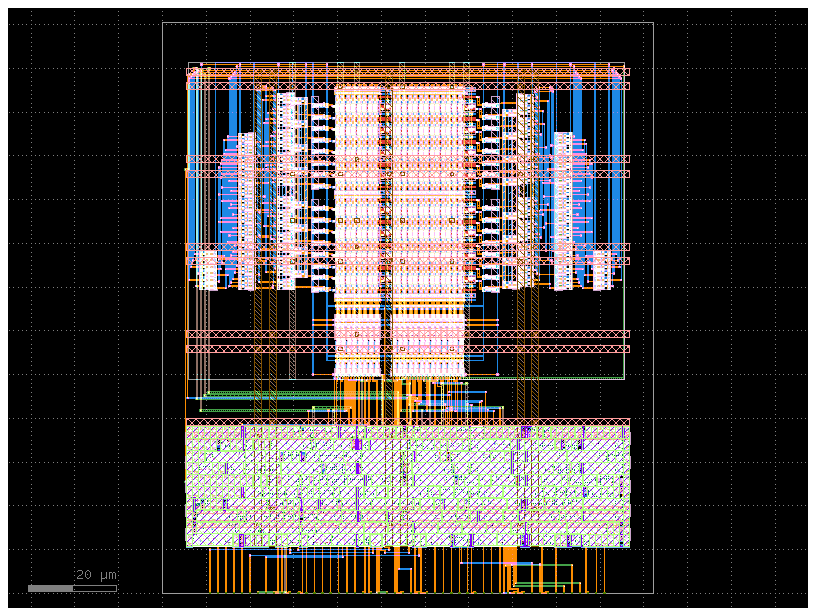

In [ ]:
import time

import gdsfactory as gf

if shutil.which("librelane"):
    t0 = time.time()
    memory = GainCellCompiler(st_cfg, tech).memory("build/memory", name="nb_mem16x20", banked=False)
    m = memory.metrics
    print(f"{memory.name} in {time.time() - t0:.0f} s: {m['bits']} bits, {m['die_area_um2']:.0f} um2 "
          f"({m['area_per_bit_um2']:.1f} um2/bit); the macro alone {m['macro_area_um2']:.0f} um2")
    print(f"controller: {m['logic_cells']} cells ({m['flops']} flops and latches), {m['controller_cell_area_um2']:.0f} um2")
    for corner, t in m["timing"].items():
        print(f"  {corner}: setup slack {t['setup_ns']:.2f} ns, hold slack {t['hold_ns']:.2f} ns")
    print(f"DRC {m['drc_errors']}, LVS {m['lvs_errors']}; gate level: {memory.gate_level.strip().splitlines()[-2]}")
    gf.import_gds(memory.file(".gds")).plot(show_labels=False)
else:
    print("librelane is not on PATH (locally: start Jupyter from the nix shell; on Colab: set INSTALL_LIBRELANE = True in the setup)")

## 22. The defaults

Everything above, with nothing chosen: `ArrayConfig(rows, cols)` and `build()`.

| Default | Why | Opt out |
|---|---|---|
| The whole memory: array, drivers, column circuits and the row decoder | a macro that takes `addr`/`we`/`re`/`din` and gives `dout` | `decoded=False`, `macro=False` (`--no-decoded`, `--no-macro`) |
| LVT write, 0.35 um, with a 0.5 um `mr` (`BitcellConfig()`) | a written '0' reads back at every corner with no extra supply; 12x the plain cell's retention; +5% area | `BitcellConfig.plain()` (`--plain-cell`) |
| Replica column | it times the read, and self-timed reads need it; +0.7 to 1.3% area | `replica_column=False` (`--no-replica`) |
| Self-timed reads (with the replica) | no fixed read time is right at every corner; +2 to 6% area | `self_timed_read=False` (`--no-self-timed`) |
| In-macro refresh (with self-timed reads) | a refresh's data never leaves the macro: nothing to time through the controller; +4 to 9% area (none at 2 x 128x128, where the central decoder is taller than the banks), +9 to 17% read energy | `refresh_in_macro=False` (`--no-refresh-in-macro`) |
| Two banks around one decoder | 13 to 24% less area per bit | `banked=False` (`--one-bank`) |
| Straps and 4x drivers from 64 columns | 64 columns: 1.78 -> 1.09 ns; 128: 3.42 -> 1.25 ns; 2.6-4% area | `wordline_straps=False`, `wordline_driver_strength=1` |

`ArrayConfig.basic()` turns all of the array's extras off at once -- the configuration sections 5-16 used.

                  bitcell: BitcellConfig(write_kind=<DeviceKind.PMOS: 'pmos'>, read_kind=<DeviceKind.NMOS: 'nmos'>, write_width=0.42, write_length=0.35, read_width=0.42, read_length=0.15, mr_length=0.5, write_flavor='lvt', read_flavor=None, pitch_x=None)
           replica_column: True
          self_timed_read: True
         refresh_in_macro: True
          wordline_straps: False
 wordline_driver_strength: 1.0



nb_macro_default: 2 banks of 16x20 = 640 bits, 168.37 x 69.47 um, 18.275 um2/bit
area per bit against section 14's one-bank plain-cell macro: -3%


DRC clean: nb_macro_default.gds


LVS match (unverified pins: vnw_0, vnw_1) (1814, 1814)


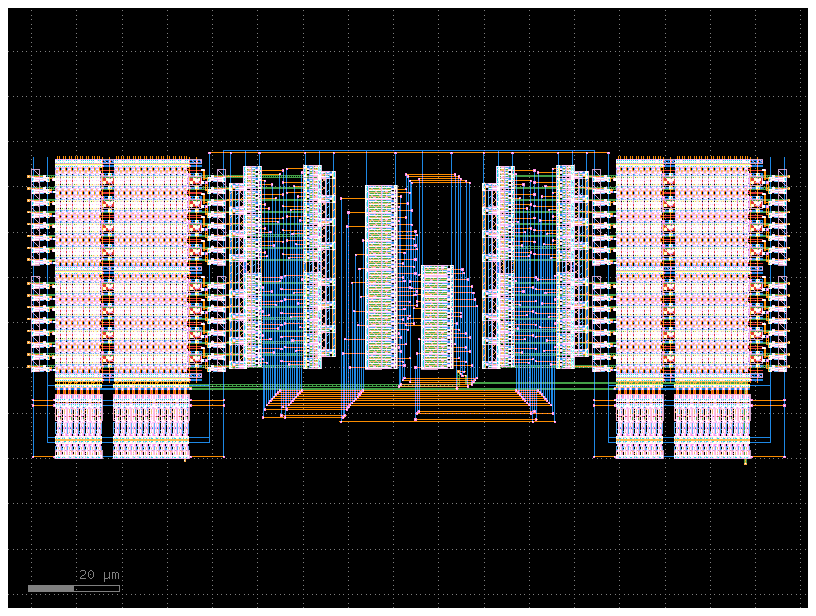

In [ ]:
default_cfg = ArrayConfig(rows=16, cols=20)
for field in ("bitcell", "replica_column", "self_timed_read", "refresh_in_macro", "wordline_straps", "wordline_driver_strength"):
    print(f"{field:>25}: {getattr(default_cfg, field)}")
default_result = GainCellCompiler(default_cfg, tech).build("build", name="nb_macro_default")
print()
print(default_result)
ratio = default_result.metrics["macro_area_per_bit_um2"] / plain.metrics["macro_area_per_bit_um2"] - 1
print(f"area per bit against section 14's one-bank plain-cell macro: {ratio:+.0%}")

default_drc = run_drc(default_result.gds)
print(default_drc)
default_lvs = lvs_layout_vs_netlist(
    default_result.gds, default_result.component.name, default_result.spice, default_result.component.name,
    workdir=Path("build/lvs_default_macro").resolve(),
    ports={p.name: tuple(p.dcenter) for p in default_result.component.ports},
)
print(default_lvs, default_lvs.net_count)
assert default_drc.clean and default_lvs.matched and not default_lvs.mismatched_nets
default_result.component.plot(show_labels=False)

## 23. A larger macro: 2 x 128x128

Everything so far was 16x20 -- small enough to simulate in minutes. The same defaults at 128x128
per bank (32 kbit, two banks) change what the macro is made of: at 128 columns the word lines are
strapped in metal3 and driven four times harder (section 19), and the array, not the periphery,
is most of the area.

In [ ]:
big_cfg = ArrayConfig(rows=128, cols=128)
print(f"straps {big_cfg.wordline_straps}, drivers x{big_cfg.wordline_driver_strength:g}, "
      f"replica {big_cfg.replica_column}, self-timed {big_cfg.self_timed_read}")
t0 = time.time()
big = GainCellCompiler(big_cfg, tech).build("build", name="nb_big128")
print(f"{big} (built in {time.time() - t0:.0f} s)")
print(f"array efficiency {big.metrics['macro_efficiency']:.0%}, against "
      f"{default_result.metrics['macro_efficiency']:.0%} for 2 x 16x20")

# what the wide-array defaults cost: the same macro without straps and with minimum drivers
plain_wl = GainCellCompiler(
    ArrayConfig(rows=128, cols=128, wordline_straps=False, wordline_driver_strength=1), tech
).build("build", name="nb_big128_nostraps")
cost = big.metrics["macro_area_um2"] / plain_wl.metrics["macro_area_um2"] - 1
print(f"straps and 4x drivers cost {cost:+.1%} area")

straps True, drivers x4, replica True, self-timed True


nb_big128: 2 banks of 128x128 = 32768 bits, 519.97 x 408.08 um, 6.476 um2/bit (built in 8 s)
array efficiency 52%, against 18% for 2 x 16x20


straps and 4x drivers cost -0.0% area


DRC clean: nb_big128.gds (211 s)


LVS match (unverified pins: vnw_0, vnw_1) (69060, 69060) (280 s)


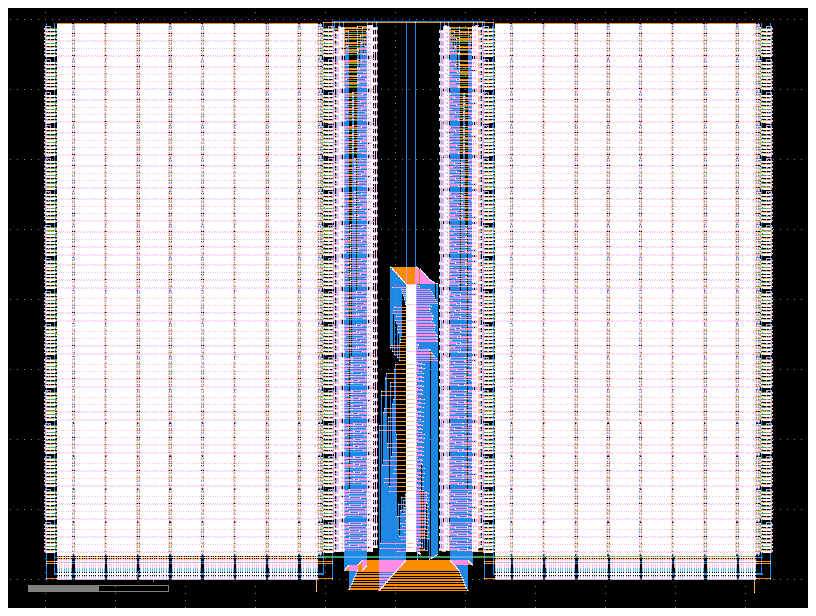

In [ ]:
# both sign-off decks and LVS, on 32k cells and their periphery (a few minutes each locally, more
# on Colab: run with FULL = True, set in the setup; the stored output below is from a full run)
if FULL:
    t0 = time.time()
    big_drc = run_drc(big.gds)
    print(big_drc, f"({time.time() - t0:.0f} s)")
    t0 = time.time()
    big_lvs = lvs_layout_vs_netlist(
        big.gds, big.component.name, big.spice, big.component.name,
        workdir=Path("build/lvs_big128").resolve(),
        ports={p.name: tuple(p.dcenter) for p in big.component.ports},
    )
    print(big_lvs, big_lvs.net_count, f"({time.time() - t0:.0f} s)")
    assert big_drc.clean and big_lvs.matched and not big_lvs.mismatched_nets
    big.component.plot(show_labels=False)
else:
    print("skipped (FULL = False): DRC and LVS of the 2 x 128x128 macro")

**The wide-array defaults come free here.** The 4x drivers do widen each outer driver column (5.4
to 8.6 um), but with straps the decoder's far outputs travel on metal3 tracks between the straps
instead of through the decoder's own channel (section 19), and at 128 rows that channel was wide:
the central decoder narrows by 6.6 um, as much as the drivers grew. At 2 x 16x128 the same
defaults cost 1.6%.

**Timing.** Characterising it works the same way, but the extracted netlist is 88 MB and each
bank's benches take about half an hour, so the cell below only runs with `SLOW = True`. Measured
(tt, 1.8 V, 25 C, worst over the end rows and columns):

| bank | access (ns) | write (ns) | precharge (ns) | `rdy` near / far (ns) | dout/rdy | '0' reads |
|---|---|---|---|---|---|---|
| 0 | 3.72 | 0.19 | 2.01 | 4.69 / 4.94 | 0.94 | ok (0.37 V) |
| 1 | 4.09 | 0.19 | 2.04 | 4.73 / 5.45 | 0.92 | ok (0.38 V) |

Against about 1.3 ns at 2 x 16x20: the word lines are not what grew -- straps and 4x drivers keep a
128-column word line quick -- but the bit lines, 128 cells long, and the 256-row decoder. Precharge
grows with the bit lines too (2 ns against 0.4). The replica column tracks it all (`rdy` comes just
after the data everywhere), so the self-timed read is as safe here as at 16x20. Characterised in 57
minutes on this machine (1.1 GB at its peak).

In [ ]:
SLOW = False  # about an hour: extraction, then both banks' benches at tt
if SLOW:
    t0 = time.time()
    big_timing = GainCellCompiler(big_cfg, tech).characterise(
        big, workdir="build/timing_big128", corners=(corners["tt"],)
    )
    print(f"characterised in {time.time() - t0:.0f} s")
    for report in big_timing:
        print(f"bank {report.bank}:")
        print(report.table())

**With its refresh controller.** The same call as for 16x20 (section 21) builds this macro and
its controller as one hard block. One thing changes: without a characterisation the controller
assumes a 4 ns read, sized for small macros -- and this one's reads end later than that already at
tt (`rdy` fires at up to 5.45 ns). The controller has to hold `re` at least until the slowest corner's
read has ended; holding it longer costs only latency, since the macro ends each read itself. So it
gets a generous bound, 12 ns: the tt cutoff (about 5.5 ns) times the slow/typical ratio measured at
16x20 (1.9x), rounded up -- or, with `SLOW = True` and the characterisation run above for every
corner, the measured one (`memory(characterisation=...)`). From the CLI: `--read-ns 12`.

Its controller has a `dout` latch and a bank multiplexer for each of 128 columns, and every column's
`din` and `dout` reach both banks, either side of the decoder: long wires across the band, so the band
is taller than its cells need, and LibreLane takes a while.

nb_big128_mem_top in 3411 s: 32768 bits, 290975 um2 (8.88 um2/bit); the macro alone 212189 um2 (6.48 um2/bit)
controller: 1210 cells (158 flops and latches), 9066 um2, 4.3% of the macro
  tt: setup slack 1.04 ns, hold slack 0.24 ns
  ss: setup slack 0.03 ns, hold slack 0.60 ns
  ff: setup slack 1.43 ns, hold slack 0.12 ns
DRC 0, LVS 0, antenna 0; gate level: PASS


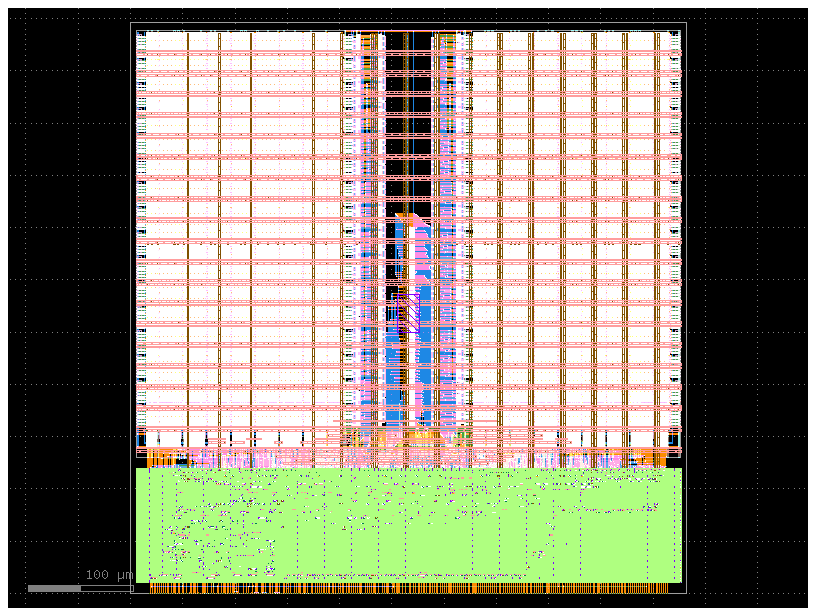

In [ ]:
from gc_compiler.rtl import ControllerTiming, default_refresh_interval_us

big_ctrl_timing = ControllerTiming(clock_ns=10.0, read_ns=12.0, interval_us=default_refresh_interval_us(big_cfg))
if shutil.which("librelane"):
    t0 = time.time()
    big_mem = GainCellCompiler(big_cfg, tech).memory("build/memory", name="nb_big128_mem", timing=big_ctrl_timing)
    m = big_mem.metrics
    print(f"{big_mem.name} in {time.time() - t0:.0f} s: {m['bits']} bits, {m['die_area_um2']:.0f} um2 "
          f"({m['area_per_bit_um2']:.2f} um2/bit); the macro alone {m['macro_area_um2']:.0f} um2 "
          f"({m['macro_area_um2'] / m['bits']:.2f} um2/bit)")
    print(f"controller: {m['logic_cells']} cells ({m['flops']} flops and latches), {m['controller_cell_area_um2']:.0f} um2, "
          f"{m['controller_cell_area_um2'] / m['macro_area_um2']:.1%} of the macro")
    for corner, t in m["timing"].items():
        loop = m["loopback"].get(corner)  # (none with the in-macro refresh: nothing leaves the macro)
        print(f"  {corner}: setup slack {t['setup_ns']:.2f} ns, hold slack {t['hold_ns']:.2f} ns"
              + (f", refresh loop-back slack {loop['slack_ns']:.1f} ns" if loop else ""))
    print(f"DRC {m['drc_errors']}, LVS {m['lvs_errors']}, antenna {m['antenna_violations']}; "
          f"gate level: {big_mem.gate_level.strip().splitlines()[-2]}")
    gf.import_gds(big_mem.file(".gds")).plot(show_labels=False)
else:
    print("librelane is not on PATH (locally: start Jupyter from the nix shell; on Colab: set INSTALL_LIBRELANE = True in the setup)")

## 24. Porting to another process

Everything the compiler knows about a process is on its `Technology`: layers and design rules, and
grouped with them the routing stack (and its LEF names), the supplies and corners, the sign-off
tools' setups, the standard-cell library's flow facts, layout choices, default device sizes, and what
was measured on it. A new PDK is a new subclass of it (`tech/sky130.py` and `tech/sg13g2.py` are the
models).

That is only worth saying if it is checked. IHP SG13G2 is a second, quite different 130 nm process:
no local interconnect (every layer role one metal up: its Metal1 plays sky130's li1), a via larger
than the contact below it, metal spacing half again sky130's, n+ implied rather than drawn. The same macro, built for each, is clean against *its own* rules (a DRC generated from the
technology's `DesignRules`); with the IHP PDK installed, IHP's KLayout decks pass it and magic/netgen
LVS matches it. Its refresh interval was measured as sky130's was (the worst of 20 mismatch dies
at the slow corner); the negative-rail driver builds on IHP's isolated p-well (nBuLay). A technology
with nothing measured makes the compiler refuse to guess.

What an adapter cannot change is listed in the [README](https://github.com/barakhoffer/gc_compiler/blob/v1.0/README.md)'s *Porting* section.

what a technology carries: layers, rules, stack, electrical, tools, policy, sizing, characterised
  sky130A     contact 0.17, first via 0.17, metal space 0.14 um, grid 0.005; contacts land on li1
  ihp-sg13g2  contact 0.16, first via 0.19, metal space 0.21 um, grid 0.005; contacts land on Metal1


sky130A     77.55 x 48.40 um, its own rules: rules clean


ihp-sg13g2  78.83 x 54.45 um, its own rules: rules clean


IHP's decks: DRC clean: nb_port_ihp.gds


LVS match (unverified pins: vnw)
sky130A     refresh interval (worst die, ss): 614 us
ihp-sg13g2  refresh interval (worst die, ss): 100 us


negative rail on SG13G2 (nBuLay), its own rules: rules clean
a technology with nothing measured: sg13g2-unmeasured has no measured refresh intervals or controller timing: characterise it, or give them (ControllerTiming(...), interval_us=...)


gc_compiler/.venv/lib/python3.12/site-packages/gdsfactory/technology/layer_views.py:1074: UserWarning: Dither pattern 'lightly hatched' does not correspond to any KLayout built-in or custom pattern! Using 'I3' instead.
  lv.to_klayout_xml(


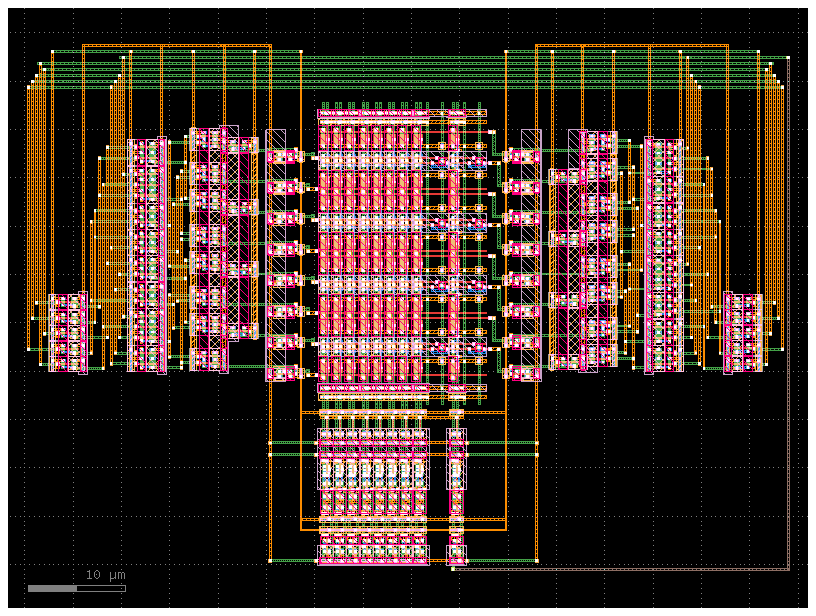

In [ ]:
import shutil
from pathlib import Path

from gc_compiler.compiler import GainCellCompiler
from gc_compiler.config import ArrayConfig
from gc_compiler.rtl import default_refresh_interval_us
from gc_compiler.tech import LayerRole, technology
from gc_compiler.tech.characterised import NotCharacterised
from gc_compiler.verify.drc import default_deck, run_drc
from gc_compiler.verify.lvs import lvs_layout_vs_netlist
from gc_compiler.verify.rules_drc import check_rules

ihp = technology("ihp-sg13g2")
print("what a technology carries:", ", ".join(
    ["layers, rules"] + [g for g in ("stack", "electrical", "tools", "policy", "sizing", "characterised")]
))
for t in (tech, ihp):
    r = t.rules
    print(f"  {t.name:11s} contact {r.cut(t.stack.contact):g}, first via {r.cut(LayerRole.MCON):g}, "
          f"metal space {r.s(LayerRole.M1):g} um, grid {r.grid:g}; contacts land on {t.stack.lef_names[t.stack.local_interconnect]}")

port = {}
for t in (tech, ihp):
    cfg = ArrayConfig.for_tech(t, rows=8, cols=8)
    result = GainCellCompiler(cfg, t).build(
        Path("build/nb_port"), name=f"nb_port_{t.cell_prefix.rstrip('_') or 'sky'}", macro=True, decoded=True, banked=False
    )
    port[t.name] = result
    box = result.component.dbbox()
    print(f"{t.name:11s} {box.width():.2f} x {box.height():.2f} um, its own rules: {check_rules(result.component, t)}")

ihp_macro = port[ihp.name]
if default_deck(tech=ihp).exists() and all(shutil.which(x) for x in ("klayout", "magic", "netgen")):
    print("IHP's decks:", run_drc(ihp_macro.gds, tech=ihp))
    cell = ihp_macro.component.name
    ports = {p.name: tuple(p.dcenter) for p in ihp_macro.component.ports}
    print(lvs_layout_vs_netlist(ihp_macro.gds, cell, ihp_macro.spice, cell, workdir="build/nb_port/lvs", ports=ports, tech=ihp))

for t in (tech, ihp):
    print(f"{t.name:11s} refresh interval (worst die, ss): {default_refresh_interval_us(ArrayConfig.for_tech(t, rows=8, cols=8), t):g} us")
neg = GainCellCompiler(ArrayConfig.for_tech(ihp, rows=4, cols=3, negative_write_wl=True), ihp).build(
    Path("build/nb_port"), name="nb_port_neg", macro=True, decoded=True, banked=False
)
print("negative rail on SG13G2 (nBuLay), its own rules:", check_rules(neg.component, ihp))


class Unmeasured(type(ihp)):
    name, characterised = "sg13g2-unmeasured", None


try:
    default_refresh_interval_us(ArrayConfig.for_tech(Unmeasured(), rows=8, cols=8), Unmeasured())
except NotCharacterised as error:
    print("a technology with nothing measured:", error)
ihp_macro.component.plot(show_labels=False)